# Análisis de Perfiles de Empleados en Trabajo Remoto

Este notebook realiza un análisis detallado de los perfiles de empleados en modalidad de trabajo remoto, enfocándose en tres grupos específicos:

1. Empleados menos motivados (con NIVEL HOMEOFFICE Alto)
2. Empleados con mayor estrés (con NIVEL HOMEOFFICE Alto)
3. Empleados que experimentan ambas condiciones

El análisis incluye perfilamiento demográfico, características laborales, patrones de trabajo remoto, y factores relacionados con motivación y estrés, junto con visualizaciones y análisis estadísticos.

In [ ]:
## 1. Preparación del Entorno y Carga de Datos

En esta sección, importamos las bibliotecas necesarias y cargamos los datos de la encuesta.

In [3]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)
warnings.filterwarnings('ignore')

# Configurar formato de visualización para pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [4]:
# Cargar los datos desde el archivo Excel
file_path = 'data_prueba2.xlsx'
df = pd.read_excel(file_path, sheet_name='Datos')

# Mostrar dimensiones y primeras filas
print(f"Dimensiones del DataFrame: {df.shape}")
df.head()

Dimensiones del DataFrame: (232, 102)


,Marca temporal,¿En qué país resides?,Tu edad está dentro del rango:,¿Tu género es?,Indica tu nivel de estudios:,Actualmente trabajas:,"En el caso de trabajar para una empresa, indica en qué país está su sede principal:",Indica los años de experiencia trabajando en empresas de desarrollo de software:,Indica los años que has trabajado de forma presencial,Por favor indica el puesto que ocupabas cuando trabajabas presencialmente en la empresa:,Por favor indica el puesto que ocupas actualmente en la empresa:,Nombre de la compañía (opcional):,Tamaño de la compañía,Tipo de empresa:,Tu empresa es:,¿En tu trabajo te comunicas con personas de distintos países?,NIVEL HOMEOFFICE,¿Cuántos días a la semana trabajas desde casa actualmente?,¿Cuántos días a la semana vas a la oficina actualmente?,¿Si tu contrato no te obliga a ir a la oficina ningún día a la semana indica en qué ocasiones se te ha solicitado ir a la oficina?,"En el caso de que tu empresa te obligue a ir a la oficina algún día a la semana, indica en qué ocasiones has tenido que asistir:","En el caso de que tu empresa te recomiende a ir a la oficina algún día a la semana, indica en qué ocasiones se te ha solicitado:","Si te ofrece tu empresa alguna clase de recompensa por ir a la oficina (parking gratuito, tickets para comidas, mejora en las instalaciones.), indica cuáles son:",¿Qué modalidad de trabajo prefieres?,La modalidad que actualmente tienes fue:,Trabajo la misma cantidad de horas que cuando trabajaba todos los días en la oficina,El intercambio de conocimiento con mis compañeros de proyecto es ahora:,La comunicación en general con mis compañeros de proyecto es ahora,La comunicación con mis jefes es ahora,Tus horarios de trabajo ahora son:,Mis reuniones ahora son:,El cansancio después de una reunión online es ahora:,Siento que mi rendimiento ahora es:,Siento que la productividad de mi equipo es:,Siento que la capacidad de mi equipo para cumplir hitos es:,Siento que mi concentración cuando estoy trabajando es:,Siento que la velocidad de mi conexión a Internet es,Siento que la eficiencia de la conexión a Internet me influye:,"Las herramientas de comunicación (Teams, Zoom, Slack,...) utilizadas por mi empresa, desde casa:",Siento que la facilidad para compartir conocimiento ahora es:,Siento que el impacto de la rotación de personal en la empresa ahora es:,"Siento que la falta de compromiso por parte de los empleados, afecta a la productividad:",Siento que el hecho de trabajar con personas de distintas culturas afecta a la productividad:,Siento que el hecho de trabajar con personas que tienen otros horarios afecta a la productividad,Siento que el hecho de trabajar con personas que se encuentran geográficamente distribuidas afecta a la productividad:,Siento que la falta de confianza entre los miembros del equipo afecta la productividad,Siento que la falta de colaboración entre los miembros del equipo afecta la productividad:,Siento que la falta de relaciones personales entre los miembros del equipo afecta la productividad:,Siento que la falta de cohesión y de espíritu de grupo afecta la productividad,Siento que los problemas de liderazgo afectan la productividad,Siento que el nivel de la definición de los requisitos de software y su calidad son ahora:,Siento que el control de los cambios de los requisitos es ahora:,Siento que la cantidad de personal cualificado en la empresa es ahora:,Siento que mi nivel de estrés es:,Siento que mi nivel de confianza para enfrentarme a los retos del trabajo es:,Siento que mis reacciones de enojo o molestia ahora son:,Siento que mi nivel de frustración con relación al trabajo es:,Siento que el nivel de presión por terminar las tareas ahora es:,Siento que la flexibilidad de mi trabajo ahora es:,Siento que los problemas tecnológicos ahora son:,Siento que la facilidad para trabajar en equipos distribuidos es:,Siento que los problemas que aparecen por las diferencias culturales ahora son:,Siento que la aplicación de metodología ágiles ahora es:,Si

## 2. Exploración y Limpieza de Datos

Examinamos la estructura de los datos, identificamos valores faltantes y realizamos transformaciones necesarias.

In [5]:
# Verificar tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Columns: 102 entries, Marca temporal to Lead
dtypes: datetime64[ns](1), int64(1), object(100)
memory usage: 185.0+ KB


In [6]:
# Verificar valores faltantes
missing_values = df.isnull().sum()
print("Columnas con valores faltantes:")
print(missing_values[missing_values > 0])

# Porcentaje de valores faltantes
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPorcentaje de valores faltantes por columna:")
print(missing_percentage[missing_percentage > 0])

Columnas con valores faltantes:
En el caso de trabajar para una empresa, indica en qué país está su sede principal:                                                                                    9
Nombre de la compañía (opcional):                                                                                                                                    106
¿Si tu contrato no te obliga a ir a la oficina ningún día a la semana indica en qué ocasiones se te ha solicitado ir a la oficina?                                    61
En el caso de que tu empresa te obligue a ir a la oficina algún día a la semana, indica en qué ocasiones has tenido que asistir:                                     110
En el caso de que tu empresa te recomiende a ir a la oficina algún día a la semana, indica en qué ocasiones se te ha solicitado:                                     101
Si te ofrece tu empresa alguna clase de recompensa por ir a la oficina (parking gratuito, tickets para comidas, mejora en l

In [7]:
# Verificar las columnas clave para nuestro análisis
key_columns = [
    "NIVEL HOMEOFFICE",
    "Siento que mi nivel de motivación en el trabajo es:",
    "Siento que mi nivel de estrés es:"
]

for col in key_columns:
    if col in df.columns:
        print(f"Valores únicos en {col}:")
        print(df[col].value_counts(dropna=False))
        print("\n")
    else:
        print(f"Columna '{col}' no encontrada en el DataFrame.")

Valores únicos en NIVEL HOMEOFFICE:
NIVEL HOMEOFFICE
Alto    194
Bajo     38
Name: count, dtype: int64


Valores únicos en Siento que mi nivel de motivación en el trabajo es::
Siento que mi nivel de motivación en el trabajo es:
Mayor que cuando iba todos los días a la oficina          85
Igual que cuando iba todos los días a la oficina          74
Mucho Mayor que cuando iba todos los días a la oficina    44
Menor que cuando iba todos los días a la oficina          26
Mucho menor que cuando iba todos los días a la oficina     3
Name: count, dtype: int64


Valores únicos en Siento que mi nivel de estrés es::
Siento que mi nivel de estrés es:
Menor que cuando iba todos los días a la oficina          78
Mucho menor que cuando iba todos los días a la oficina    63
Igual que cuando iba todos los días a la oficina          47
Mayor que cuando iba todos los días a la oficina          37
Mucho Mayor que cuando iba todos los días a la oficina     7
Name: count, dtype: int64




In [9]:
# Limpieza básica de datos

# 1. Eliminar filas con valores faltantes en las columnas clave para nuestro análisis
df_clean = df.dropna(subset=key_columns)

# 2. Para otras columnas, podemos llenar los valores faltantes con la moda (para variables categóricas)
# o usar estrategias específicas según el contexto
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        # Llenar con la moda (valor más frecuente)
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)

# 3. Verificar que no queden valores faltantes en las columnas clave
print("Valores faltantes después de la limpieza en columnas clave:")
for col in key_columns:
    print(f"{col}: {df_clean[col].isnull().sum()}")

# Mostrar dimensiones después de la limpieza
print(f"\nDimensiones del DataFrame después de la limpieza: {df_clean.shape}")

Valores faltantes después de la limpieza en columnas clave:
NIVEL HOMEOFFICE: 0
Siento que mi nivel de motivación en el trabajo es:: 0
Siento que mi nivel de estrés es:: 0

Dimensiones del DataFrame después de la limpieza: (232, 102)


## 3. Identificación de los Grupos de Interés

Definimos y extraemos los tres grupos específicos de empleados según los criterios establecidos.

In [10]:
# Filtrar solo empleados con NIVEL HOMEOFFICE Alto
remote_employees = df_clean[df_clean["NIVEL HOMEOFFICE"] == "Alto"]
print(f"Empleados con nivel HomeOffice Alto: {len(remote_employees)}")

# Grupo 1: Empleados menos motivados (con NIVEL HOMEOFFICE Alto)
less_motivated = remote_employees[
    (remote_employees["Siento que mi nivel de motivación en el trabajo es:"] == "Menor que cuando iba todos los días a la oficina") | 
    (remote_employees["Siento que mi nivel de motivación en el trabajo es:"] == "Mucho menor que cuando iba todos los días a la oficina")
]
print(f"Grupo 1 - Empleados menos motivados: {len(less_motivated)}")

# Grupo 2: Empleados con mayor estrés (con NIVEL HOMEOFFICE Alto)
more_stressed = remote_employees[
    (remote_employees["Siento que mi nivel de estrés es:"] == "Mayor que cuando iba todos los días a la oficina") | 
    (remote_employees["Siento que mi nivel de estrés es:"] == "Mucho mayor que cuando iba todos los días a la oficina")
]
print(f"Grupo 2 - Empleados con mayor estrés: {len(more_stressed)}")

# Grupo 3: Empleados que experimentan ambas condiciones (con NIVEL HOMEOFFICE Alto)
both_conditions = remote_employees[
    ((remote_employees["Siento que mi nivel de motivación en el trabajo es:"] == "Menor que cuando iba todos los días a la oficina") | 
     (remote_employees["Siento que mi nivel de motivación en el trabajo es:"] == "Mucho menor que cuando iba todos los días a la oficina")) & 
    ((remote_employees["Siento que mi nivel de estrés es:"] == "Mayor que cuando iba todos los días a la oficina") | 
     (remote_employees["Siento que mi nivel de estrés es:"] == "Mucho mayor que cuando iba todos los días a la oficina"))
]
print(f"Grupo 3 - Empleados con ambas condiciones: {len(both_conditions)}")

Empleados con nivel HomeOffice Alto: 194
Grupo 1 - Empleados menos motivados: 21
Grupo 2 - Empleados con mayor estrés: 32
Grupo 3 - Empleados con ambas condiciones: 5


In [11]:
# Crear una columna que identifique a qué grupo pertenece cada empleado remoto
remote_employees['grupo'] = 'Otros empleados remotos'

# Marcar los empleados menos motivados
remote_employees.loc[less_motivated.index, 'grupo'] = 'Menos motivados'

# Marcar los empleados con mayor estrés
remote_employees.loc[more_stressed.index, 'grupo'] = 'Mayor estrés'

# Marcar los empleados con ambas condiciones (sobrescribiendo las marcas anteriores)
remote_employees.loc[both_conditions.index, 'grupo'] = 'Ambas condiciones'

# Verificar la distribución de los grupos
grupos_count = remote_employees['grupo'].value_counts()
print("Distribución de empleados remotos por grupo:")
print(grupos_count)
print(f"Porcentaje de empleados en grupos específicos: {(grupos_count.sum() - grupos_count['Otros empleados remotos']) / len(remote_employees) * 100:.2f}%")

Distribución de empleados remotos por grupo:
grupo
Otros empleados remotos    146
Mayor estrés                27
Menos motivados             16
Ambas condiciones            5
Name: count, dtype: int64
Porcentaje de empleados en grupos específicos: 24.74%


## 4. Análisis Demográfico de los Grupos

Analizamos las características demográficas de cada grupo y creamos visualizaciones comparativas.

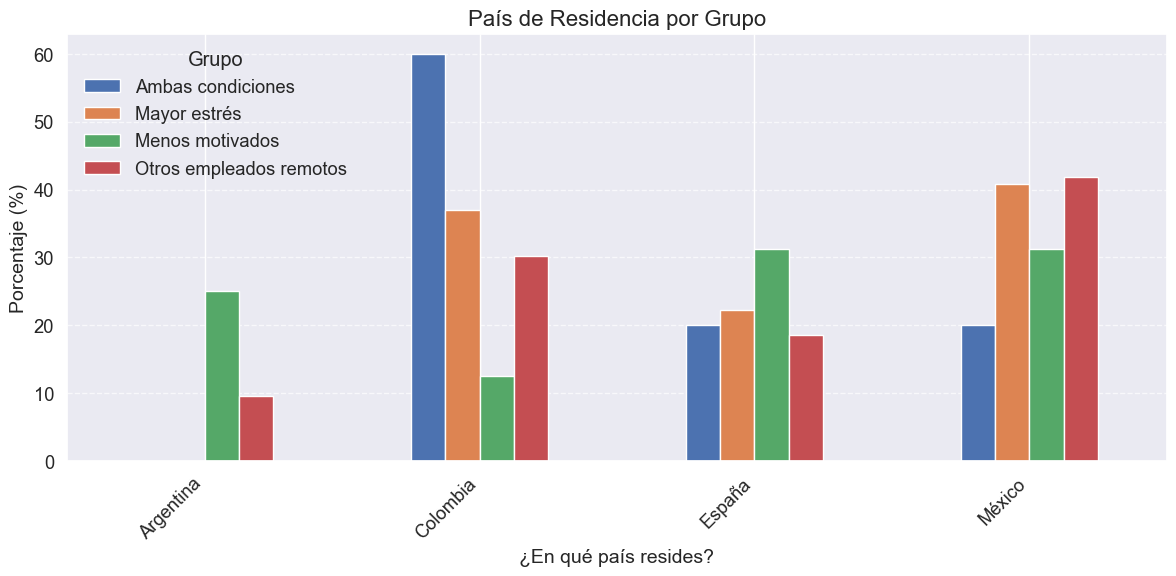


Distribución de País de Residencia por grupo (%):

grupo                  Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
¿En qué país resides?                                                                           
Argentina                            0.0           0.0             25.0                      9.6
Colombia                            60.0          37.0             12.5                     30.1
España                              20.0          22.2             31.2                     18.5
México                              20.0          40.7             31.2                     41.8


grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
¿En qué país resides?,,,,
Argentina,0.0,0.0,25.0,9.6
Colombia,60.0,37.0,12.5,30.1
España,20.0,22.2,31.2,18.5
México,20.0,40.7,31.2,41.8


In [54]:
def demographic_analysis(df, column, title, figsize=(12, 6)):
    """
    Realiza un análisis demográfico con visualización y tabla de porcentajes.
    
    Parámetros:
    - df: DataFrame de pandas
    - column: Nombre de la columna a analizar
    - title: Título para la visualización
    - figsize: Tamaño de la figura (opcional)
    
    Retorna:
    - Tabla de porcentajes cruzados
    """
    # Crear crosstab para la variable demográfica por grupo
    cross_tab = pd.crosstab(df[column], df['grupo'], normalize='columns') * 100
    
    # Crear visualización
    fig, ax = plt.subplots(figsize=figsize)
    cross_tab.plot(kind='bar', ax=ax)
    
    plt.title(f"{title} por Grupo", fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel("Porcentaje (%)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Grupo")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla de porcentajes
    print(f"\nDistribución de {title} por grupo (%):\n")
    print(cross_tab.round(1))
    
    return cross_tab.round(1)

    # Análisis demográfico: País de residencia
demographic_analysis(remote_employees, "¿En qué país resides?", "País de Residencia")

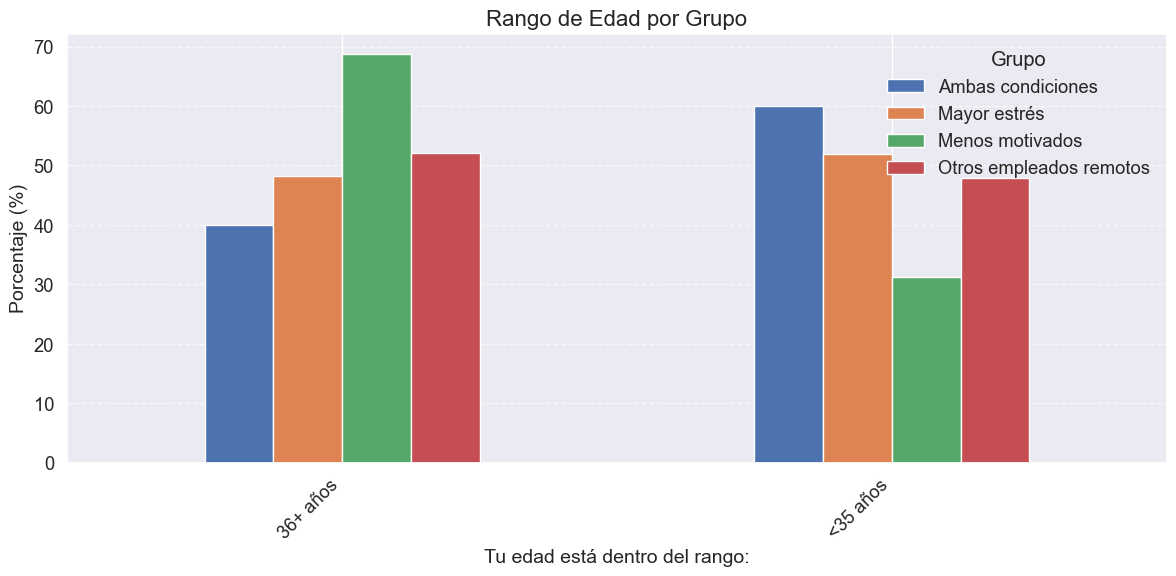


Distribución de Rango de Edad por grupo (%):

grupo                           Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Tu edad está dentro del rango:                                                                           
36+ años                                     40.0          48.1             68.8                     52.1
<35 años                                     60.0          51.9             31.2                     47.9


grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
Tu edad está dentro del rango:,,,,
36+ años,40.0,48.1,68.8,52.1
<35 años,60.0,51.9,31.2,47.9


In [55]:
# Análisis demográfico: Rango de edad
demographic_analysis(remote_employees, "Tu edad está dentro del rango:", "Rango de Edad")

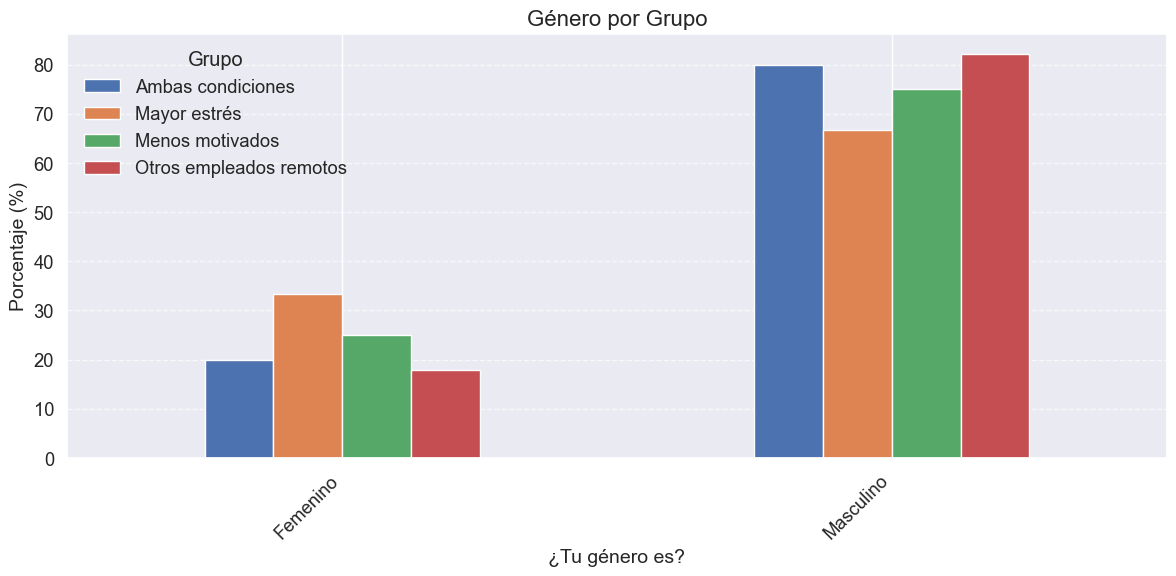


Distribución de Género por grupo (%):

grupo           Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
¿Tu género es?                                                                           
Femenino                     20.0          33.3             25.0                     17.8
Masculino                    80.0          66.7             75.0                     82.2


grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
¿Tu género es?,,,,
Femenino,20.0,33.3,25.0,17.8
Masculino,80.0,66.7,75.0,82.2


In [56]:
# Análisis demográfico: Género
demographic_analysis(remote_employees, "¿Tu género es?", "Género")

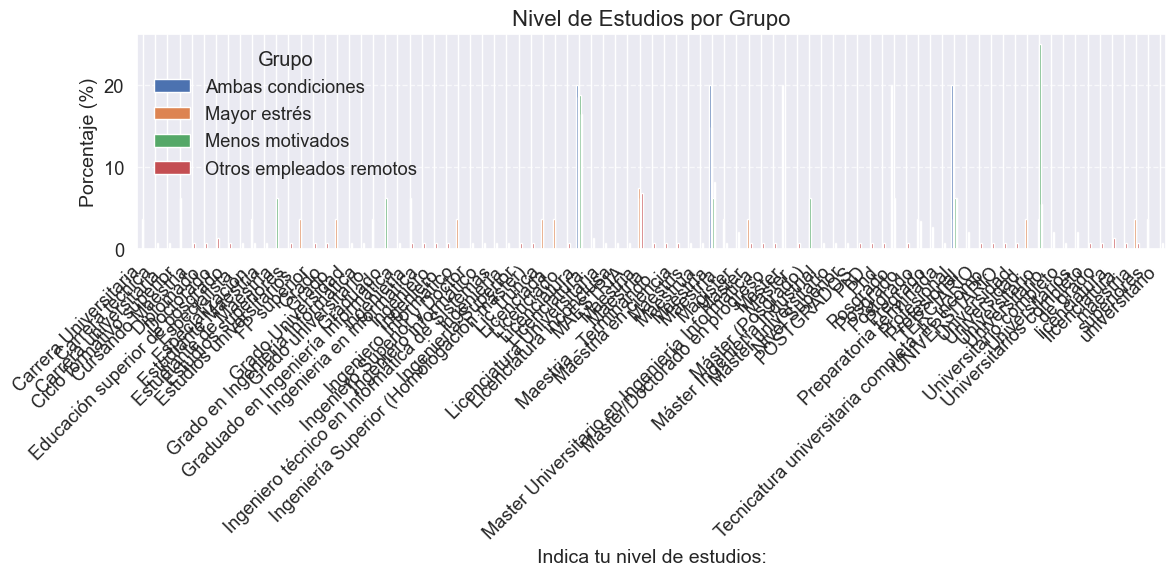


Distribución de Nivel de Estudios por grupo (%):

grupo                                            Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Indica tu nivel de estudios:                                                                                              
Carrera Universitaria                                          0.0           3.7              0.0                      0.0
Carrera tecnica                                                0.0           0.0              0.0                      0.7
Carrera universitaria                                          0.0           0.0              0.0                      0.7
Ciclo formativo superior                                       0.0           0.0              6.2                      0.0
Cursando Maestria                                              0.0           0.0              0.0                      0.7
Diplomado                                                      0.0           0.0        

grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
Indica tu nivel de estudios:,,,,
Carrera Universitaria,0.0,3.7,0.0,0.0
Carrera tecnica,0.0,0.0,0.0,0.7
Carrera universitaria,0.0,0.0,0.0,0.7
Ciclo formativo superior,0.0,0.0,6.2,0.0
Cursando Maestria,0.0,0.0,0.0,0.7
Diplomado,0.0,0.0,0.0,0.7
Doctorado,0.0,0.0,0.0,1.4
Educación superior de posgrado,0.0,0.0,0.0,0.7
Especialista,0.0,0.0,0.0,0.7


In [57]:
# Análisis demográfico: Nivel de estudios
demographic_analysis(remote_employees, "Indica tu nivel de estudios:", "Nivel de Estudios")

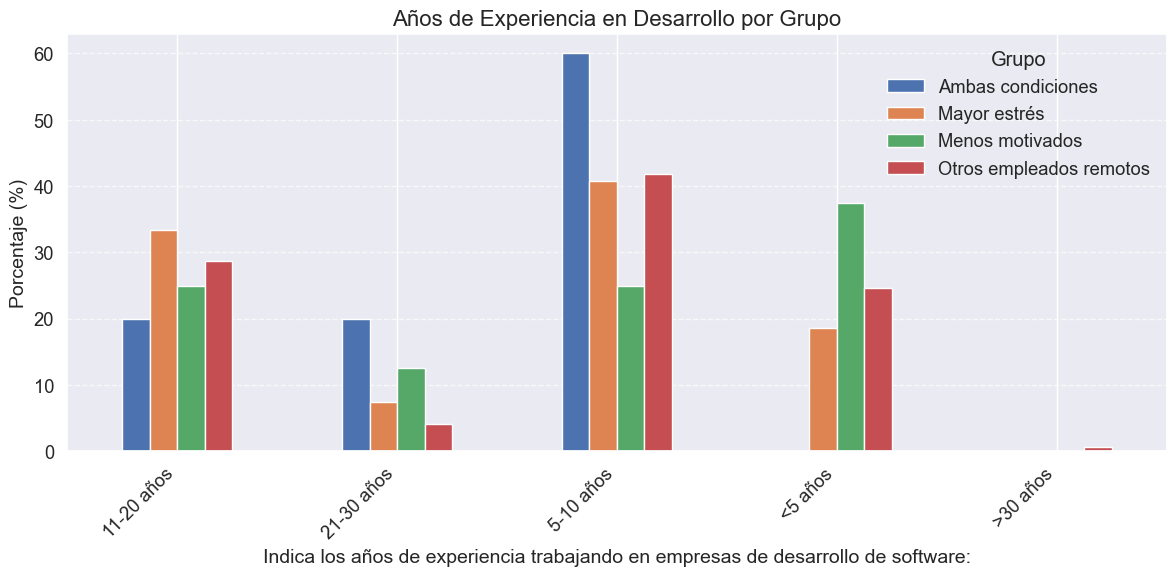


Distribución de Años de Experiencia en Desarrollo por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Indica los años de experiencia trabajando en em...                                                                           
11-20 años                                                       20.0          33.3             25.0                     28.8
21-30 años                                                       20.0           7.4             12.5                      4.1
5-10 años                                                        60.0          40.7             25.0                     41.8
<5 años                                                           0.0          18.5             37.5                     24.7
>30 años                                                          0.0           0.0              0.0                      0.7


grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
Indica los años de experiencia trabajando en empresas de desarrollo de software:,,,,
11-20 años,20.0,33.3,25.0,28.8
21-30 años,20.0,7.4,12.5,4.1
5-10 años,60.0,40.7,25.0,41.8
<5 años,0.0,18.5,37.5,24.7
>30 años,0.0,0.0,0.0,0.7


In [58]:
# Análisis demográfico: Años de experiencia en desarrollo de software
demographic_analysis(remote_employees, "Indica los años de experiencia trabajando en empresas de desarrollo de software:", "Años de Experiencia en Desarrollo")

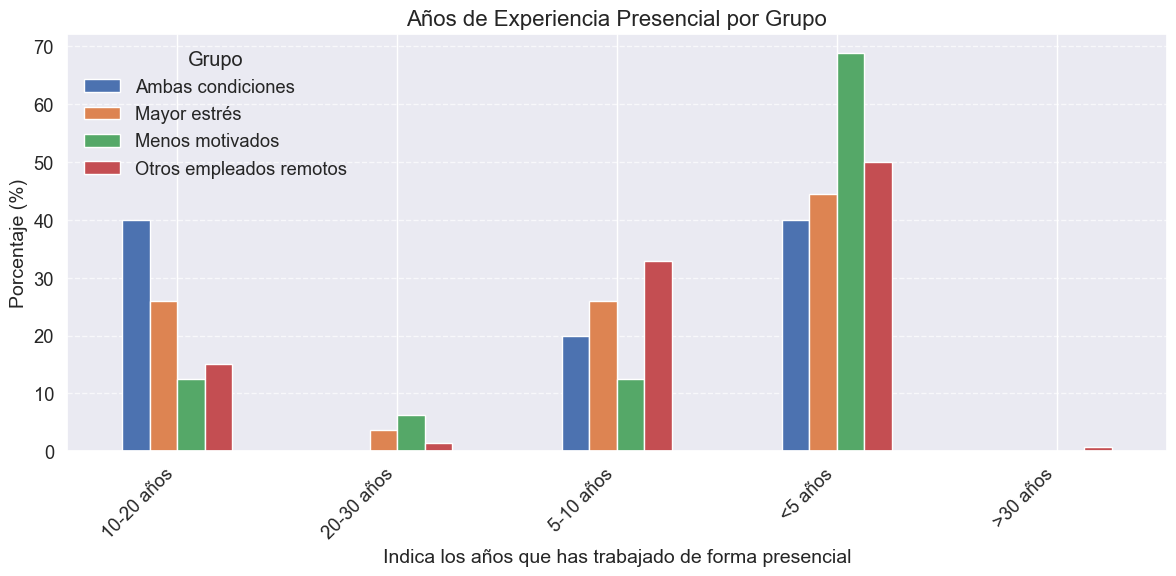


Distribución de Años de Experiencia Presencial por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Indica los años que has trabajado de forma pres...                                                                           
10-20 años                                                       40.0          25.9             12.5                     15.1
20-30 años                                                        0.0           3.7              6.2                      1.4
5-10 años                                                        20.0          25.9             12.5                     32.9
<5 años                                                          40.0          44.4             68.8                     50.0
>30 años                                                          0.0           0.0              0.0                      0.7


grupo,Ambas condiciones,Mayor estrés,Menos motivados,Otros empleados remotos
Indica los años que has trabajado de forma presencial,,,,
10-20 años,40.0,25.9,12.5,15.1
20-30 años,0.0,3.7,6.2,1.4
5-10 años,20.0,25.9,12.5,32.9
<5 años,40.0,44.4,68.8,50.0
>30 años,0.0,0.0,0.0,0.7


In [59]:
# Análisis demográfico: Años de experiencia trabajando de forma presencial
demographic_analysis(remote_employees, "Indica los años que has trabajado de forma presencial", "Años de Experiencia Presencial")

In [60]:
# Visualización interactiva con Plotly: Comparación de países por grupo
country_group = pd.crosstab(remote_employees['¿En qué país resides?'], remote_employees['grupo'])

fig = px.bar(country_group, 
             title='Distribución de Países por Grupo',
             labels={'index': 'País', 'value': 'Número de Empleados', 'grupo': 'Grupo'},
             barmode='group',
             height=600)

fig.update_layout(
    xaxis_title='País',
    yaxis_title='Número de Empleados',
    legend_title='Grupo',
    font=dict(size=12)
)

fig.show()

<Figure size 1200x800 with 0 Axes>

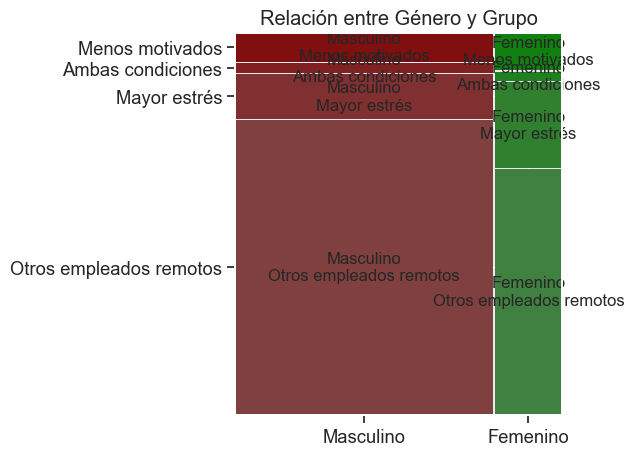

In [20]:
# Crear un gráfico de mosaico para visualizar la relación entre género y grupo
from statsmodels.graphics.mosaicplot import mosaic

plt.figure(figsize=(12, 8))
mosaic(remote_employees, ['¿Tu género es?', 'grupo'], title='Relación entre Género y Grupo')
plt.tight_layout()
plt.show()

## 5. Análisis de Información Laboral

Examinamos las características laborales de cada grupo, incluyendo tipos de puestos, tamaño de empresa, y preferencias de modalidad de trabajo.

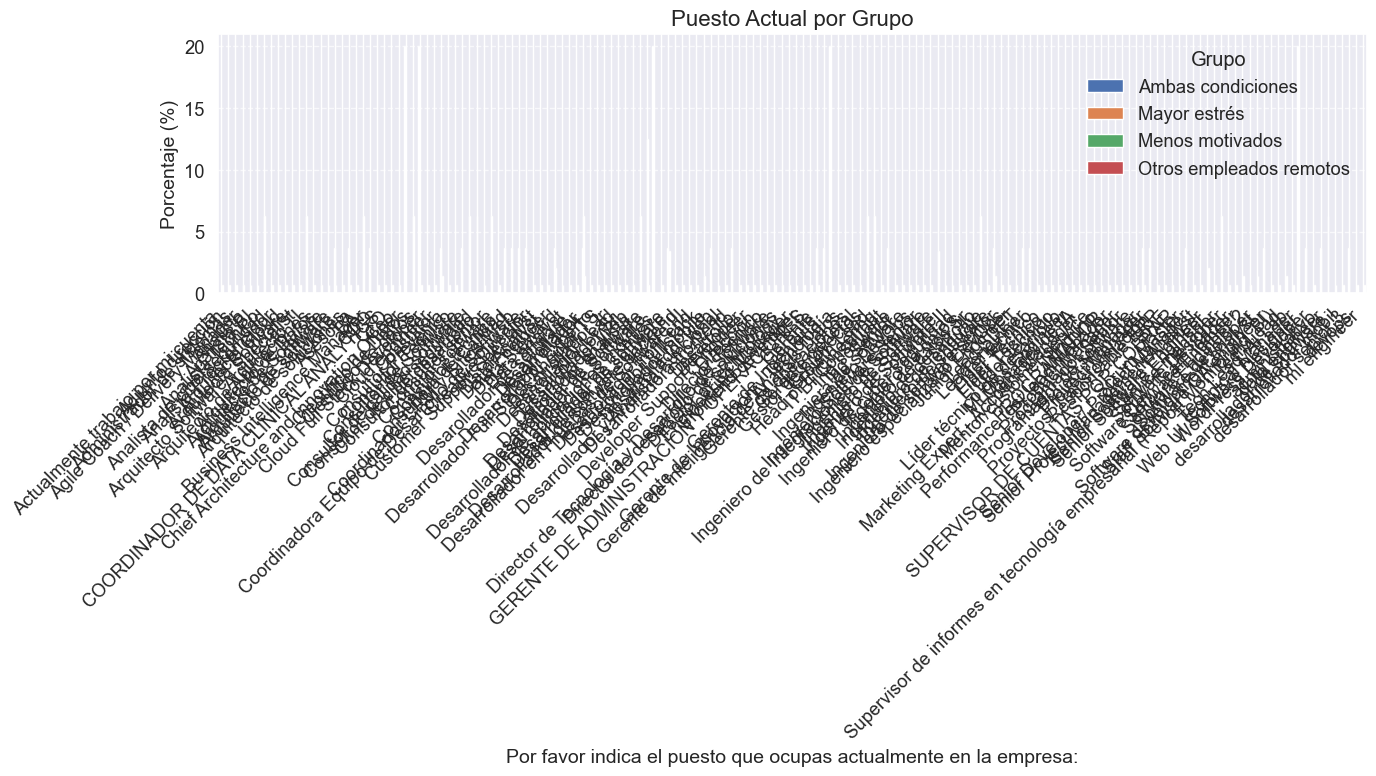


Distribución de Puesto Actual por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Por favor indica el puesto que ocupas actualmen...                                                                           
Actualmente trabajo por mi cuenta                                 0.0           0.0              0.0                      0.7
Adjunto dirección                                                 0.0           0.0              0.0                      0.7
Administrador de sistemas                                         0.0           0.0              0.0                      0.7
Agile Coach / Delivery Manager                                    0.0           0.0              0.0                      0.7
Analista                                                          0.0           0.0              0.0                      0.7
...                                                               ...  

In [61]:
# Analizar puestos actuales por grupo
positions_by_group = demographic_analysis(remote_employees, 
                                         "Por favor indica el puesto que ocupas actualmente en la empresa:", 
                                         "Puesto Actual", 
                                         figsize=(14, 8))

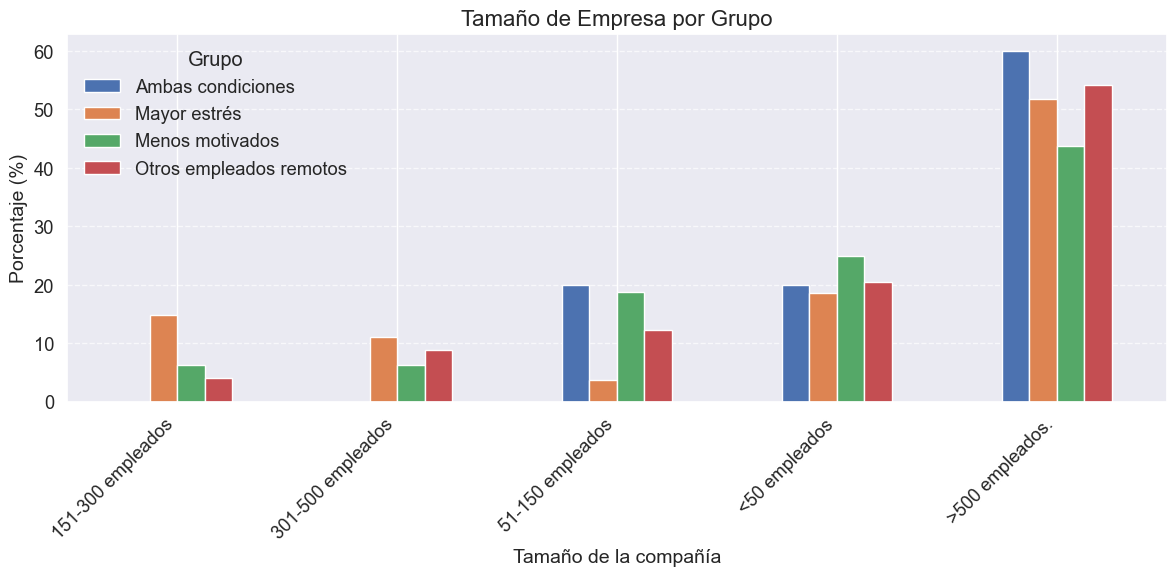


Distribución de Tamaño de Empresa por grupo (%):

grupo                  Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Tamaño de la compañía                                                                           
151-300 empleados                    0.0          14.8              6.2                      4.1
301-500 empleados                    0.0          11.1              6.2                      8.9
51-150 empleados                    20.0           3.7             18.8                     12.3
<50 empleados                       20.0          18.5             25.0                     20.5
>500 empleados.                     60.0          51.9             43.8                     54.1


In [62]:
# Visualizar tamaño de empresa por grupo
company_size = demographic_analysis(remote_employees, "Tamaño de la compañía", "Tamaño de Empresa")

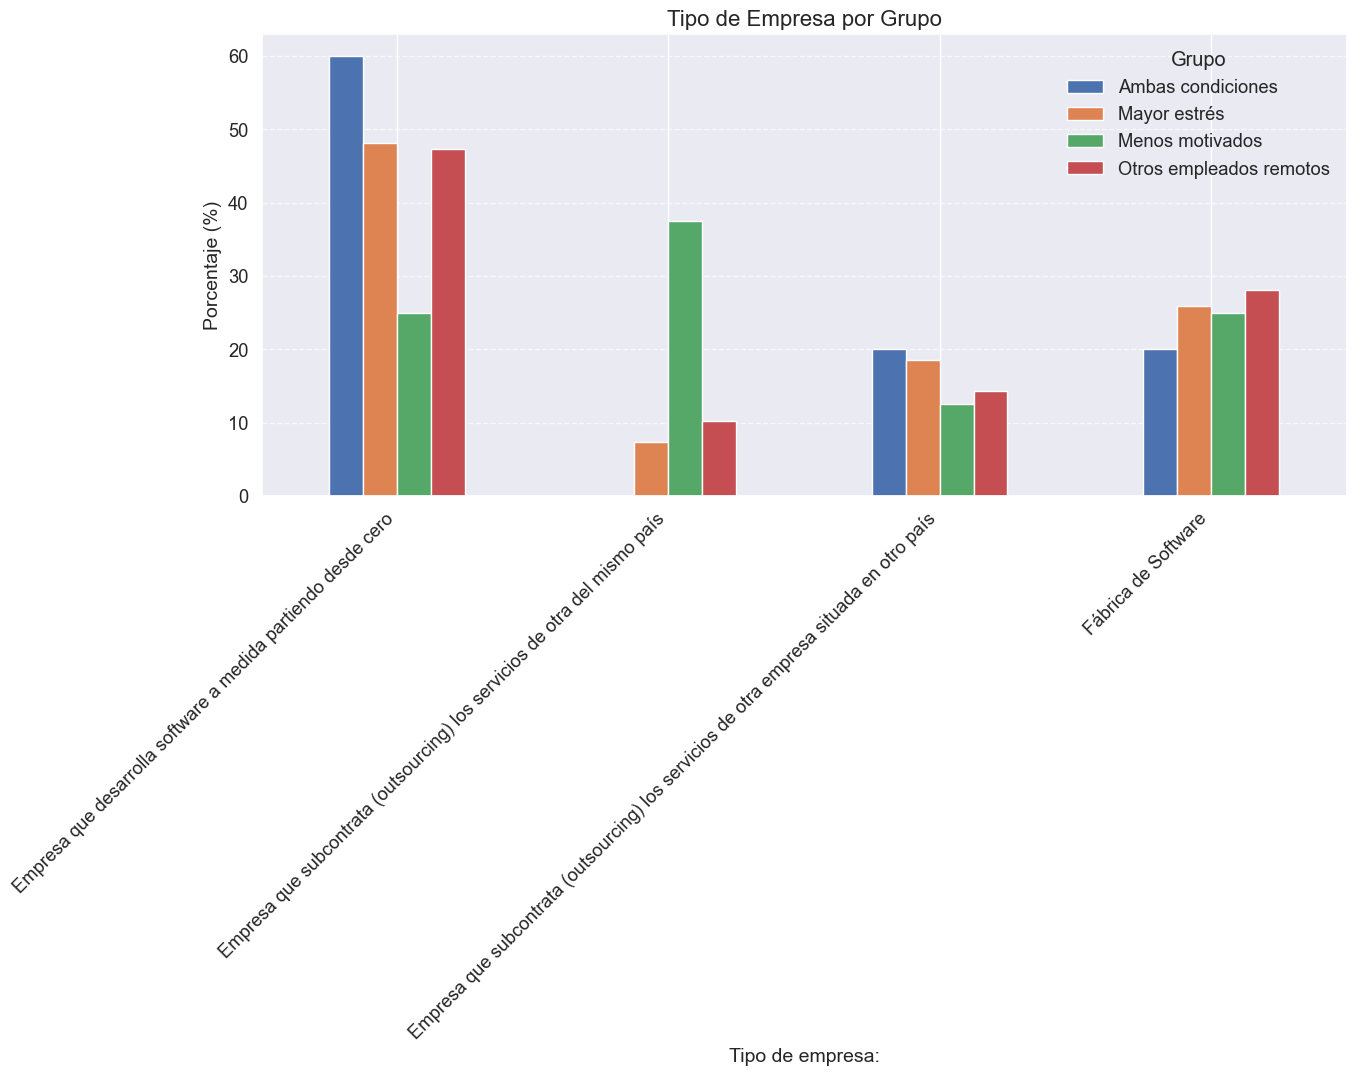


Distribución de Tipo de Empresa por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Tipo de empresa:                                                                                                             
Empresa que desarrolla software a medida partie...               60.0          48.1             25.0                     47.3
Empresa que subcontrata (outsourcing) los servi...                0.0           7.4             37.5                     10.3
Empresa que subcontrata (outsourcing) los servi...               20.0          18.5             12.5                     14.4
Fábrica de Software                                              20.0          25.9             25.0                     28.1


In [63]:
# Visualizar tipo de empresa por grupo
company_type = demographic_analysis(remote_employees, "Tipo de empresa:", "Tipo de Empresa", figsize=(14, 6))

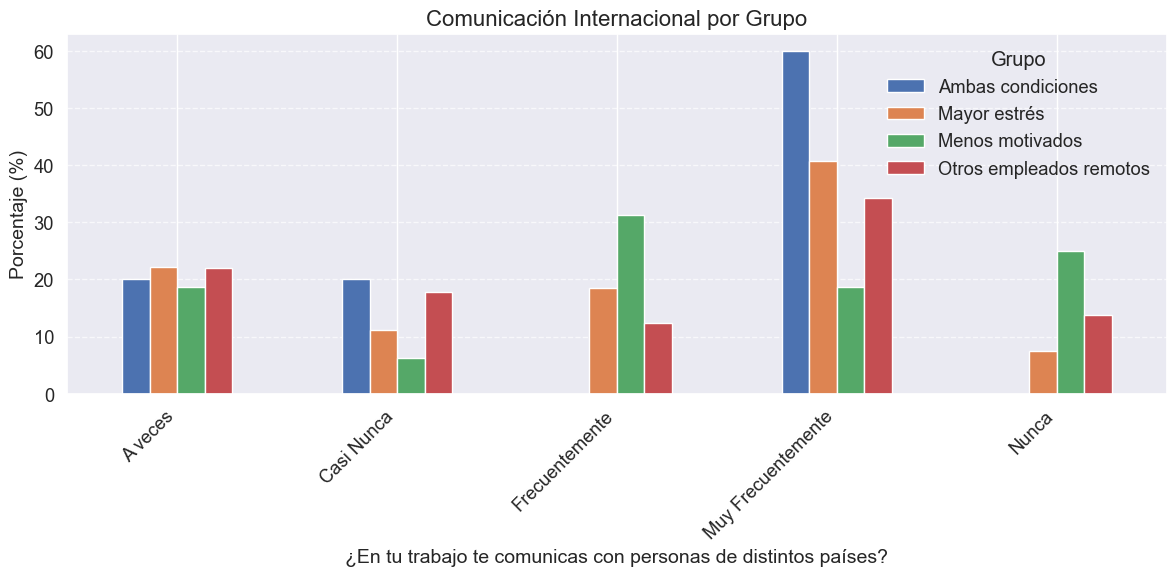


Distribución de Comunicación Internacional por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
¿En tu trabajo te comunicas con personas de dis...                                                                           
A veces                                                          20.0          22.2             18.8                     21.9
Casi Nunca                                                       20.0          11.1              6.2                     17.8
Frecuentemente                                                    0.0          18.5             31.2                     12.3
Muy Frecuentemente                                               60.0          40.7             18.8                     34.2
Nunca                                                             0.0           7.4             25.0                     13.7


In [64]:
# Visualizar frecuencia de comunicación con personas de distintos países
international_comm = demographic_analysis(remote_employees, 
                                         "¿En tu trabajo te comunicas con personas de distintos países?", 
                                         "Comunicación Internacional")

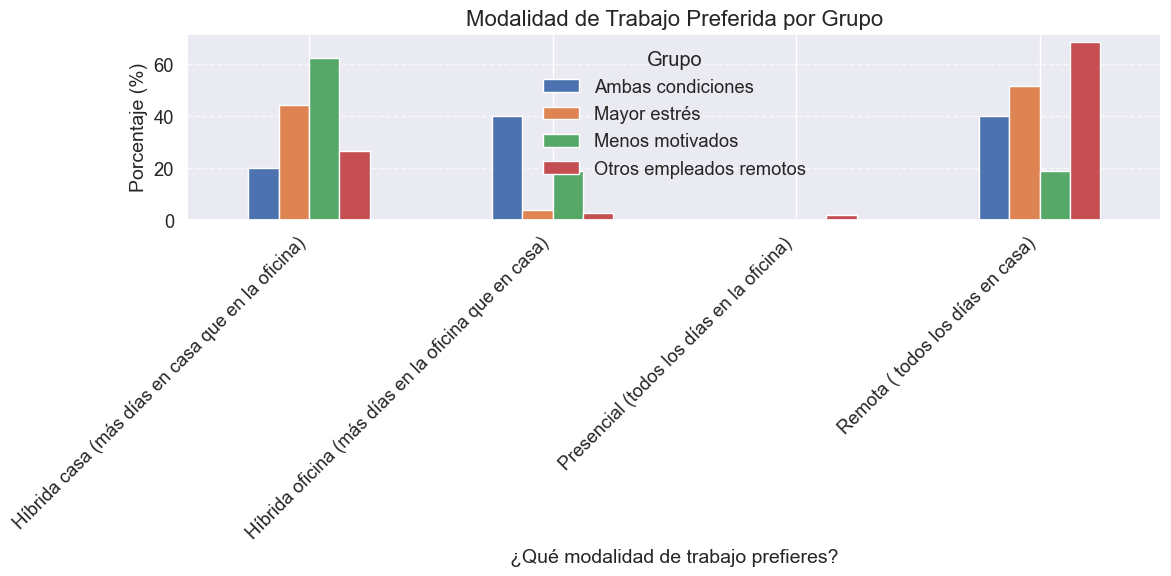


Distribución de Modalidad de Trabajo Preferida por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
¿Qué modalidad de trabajo prefieres?                                                                                         
Híbrida casa (más días en casa que en la oficina)                20.0          44.4             62.5                     26.7
Híbrida oficina (más días en la oficina que en ...               40.0           3.7             18.8                      2.7
Presencial (todos los días en la oficina)                         0.0           0.0              0.0                      2.1
Remota ( todos los días en casa)                                 40.0          51.9             18.8                     68.5


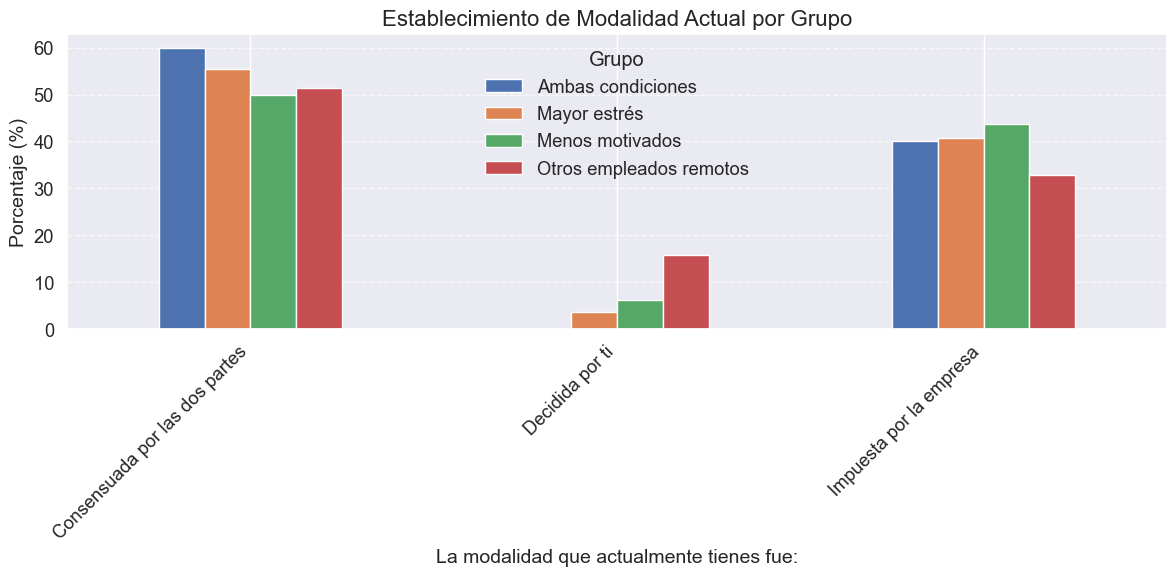


Distribución de Establecimiento de Modalidad Actual por grupo (%):

grupo                                     Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
La modalidad que actualmente tienes fue:                                                                           
Consensuada por las dos partes                         60.0          55.6             50.0                     51.4
Decidida por ti                                         0.0           3.7              6.2                     15.8
Impuesta por la empresa                                40.0          40.7             43.8                     32.9


In [65]:
# Visualizar modalidad de trabajo preferida vs. actual

# Modalidad preferida
preferred_modality = demographic_analysis(remote_employees, 
                                         "¿Qué modalidad de trabajo prefieres?", 
                                         "Modalidad de Trabajo Preferida")

# Cómo se estableció la modalidad actual
current_modality = demographic_analysis(remote_employees, 
                                       "La modalidad que actualmente tienes fue:", 
                                       "Establecimiento de Modalidad Actual")

In [26]:
# Visualización interactiva: Tamaño de empresa vs Tipo de empresa por grupo
fig = px.scatter(remote_employees, 
                x="Tamaño de la compañía", 
                y="Tipo de empresa:",
                color="grupo",
                size=[10] * len(remote_employees),  # Tamaño constante para todos los puntos
                hover_data=["¿En qué país resides?", "Tu edad está dentro del rango:", "¿Tu género es?"],
                title="Relación entre Tamaño y Tipo de Empresa por Grupo",
                height=600)

fig.update_layout(
    xaxis_title="Tamaño de Empresa",
    yaxis_title="Tipo de Empresa",
    legend_title="Grupo"
)

fig.show()

## 6. Análisis de Características del Trabajo Remoto

Examinamos cómo cada grupo experimenta el trabajo remoto, incluyendo patrones de días trabajando desde casa, cambios en horas trabajadas, e impacto en diversos aspectos laborales.

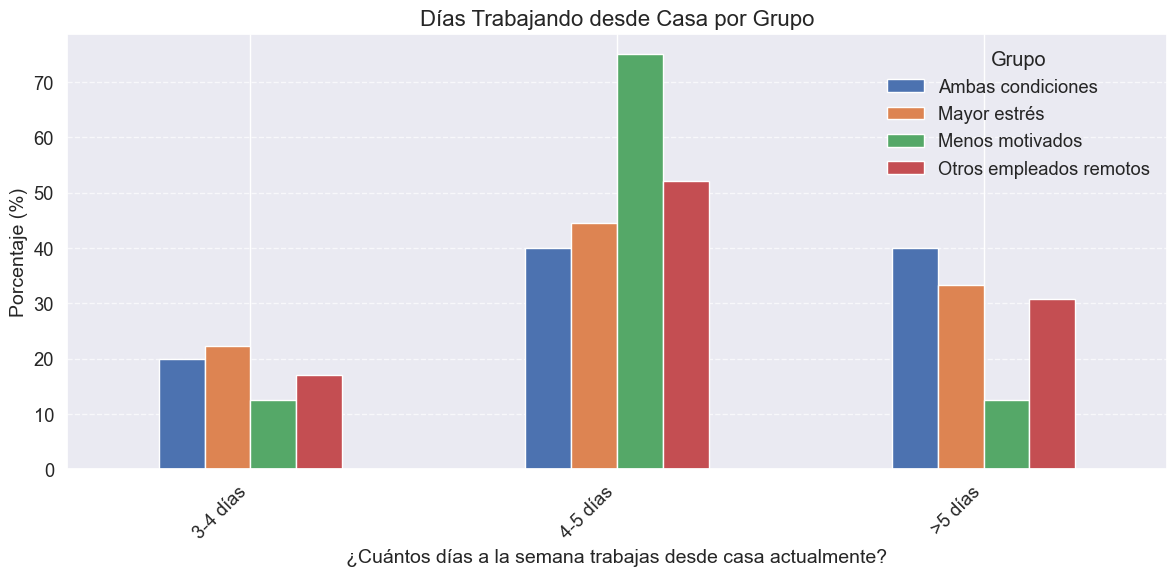


Distribución de Días Trabajando desde Casa por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
¿Cuántos días a la semana trabajas desde casa a...                                                                           
3-4 días                                                         20.0          22.2             12.5                     17.1
4-5 días                                                         40.0          44.4             75.0                     52.1
>5 días                                                          40.0          33.3             12.5                     30.8


In [66]:
# Visualizar días trabajando desde casa por grupo
days_at_home = demographic_analysis(remote_employees, 
                                   "¿Cuántos días a la semana trabajas desde casa actualmente?", 
                                   "Días Trabajando desde Casa")

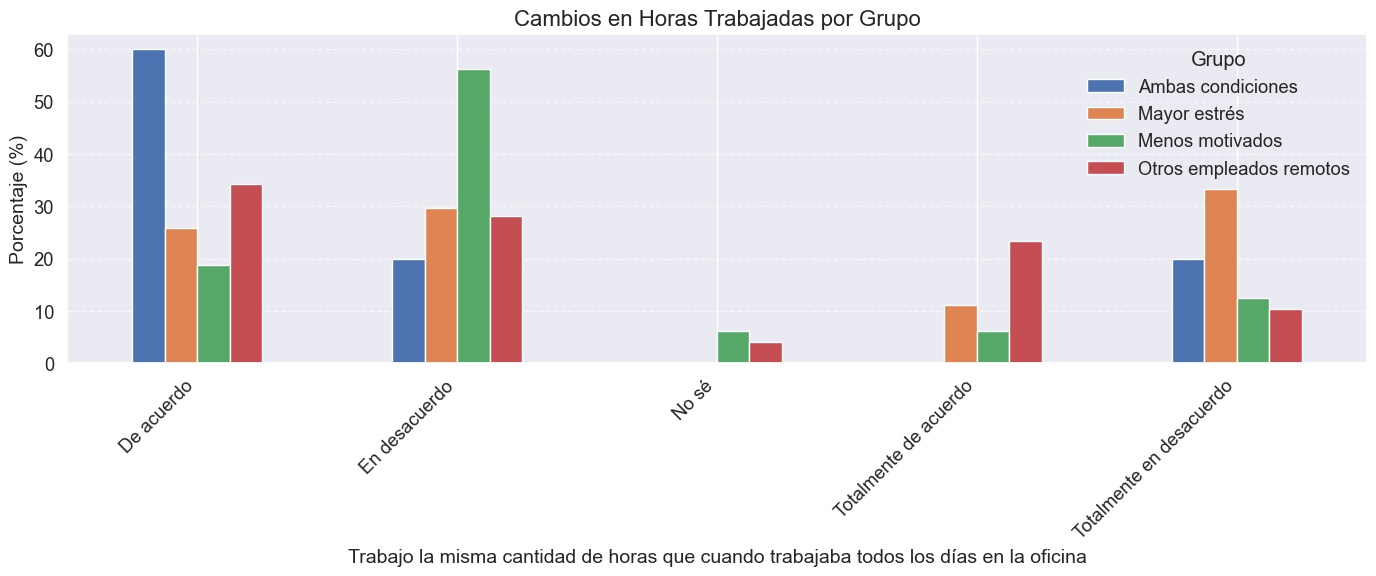


Distribución de Cambios en Horas Trabajadas por grupo (%):

grupo                                               Ambas condiciones  Mayor estrés  Menos motivados  Otros empleados remotos
Trabajo la misma cantidad de horas que cuando t...                                                                           
De acuerdo                                                       60.0          25.9             18.8                     34.2
En desacuerdo                                                    20.0          29.6             56.2                     28.1
No sé                                                             0.0           0.0              6.2                      4.1
Totalmente de acuerdo                                             0.0          11.1              6.2                     23.3
Totalmente en desacuerdo                                         20.0          33.3             12.5                     10.3


In [68]:
# Visualizar cambios en horas trabajadas
working_hours = demographic_analysis(remote_employees, 
                                    "Trabajo la misma cantidad de horas que cuando trabajaba todos los días en la oficina", 
                                    "Cambios en Horas Trabajadas", 
                                    figsize=(14, 6))

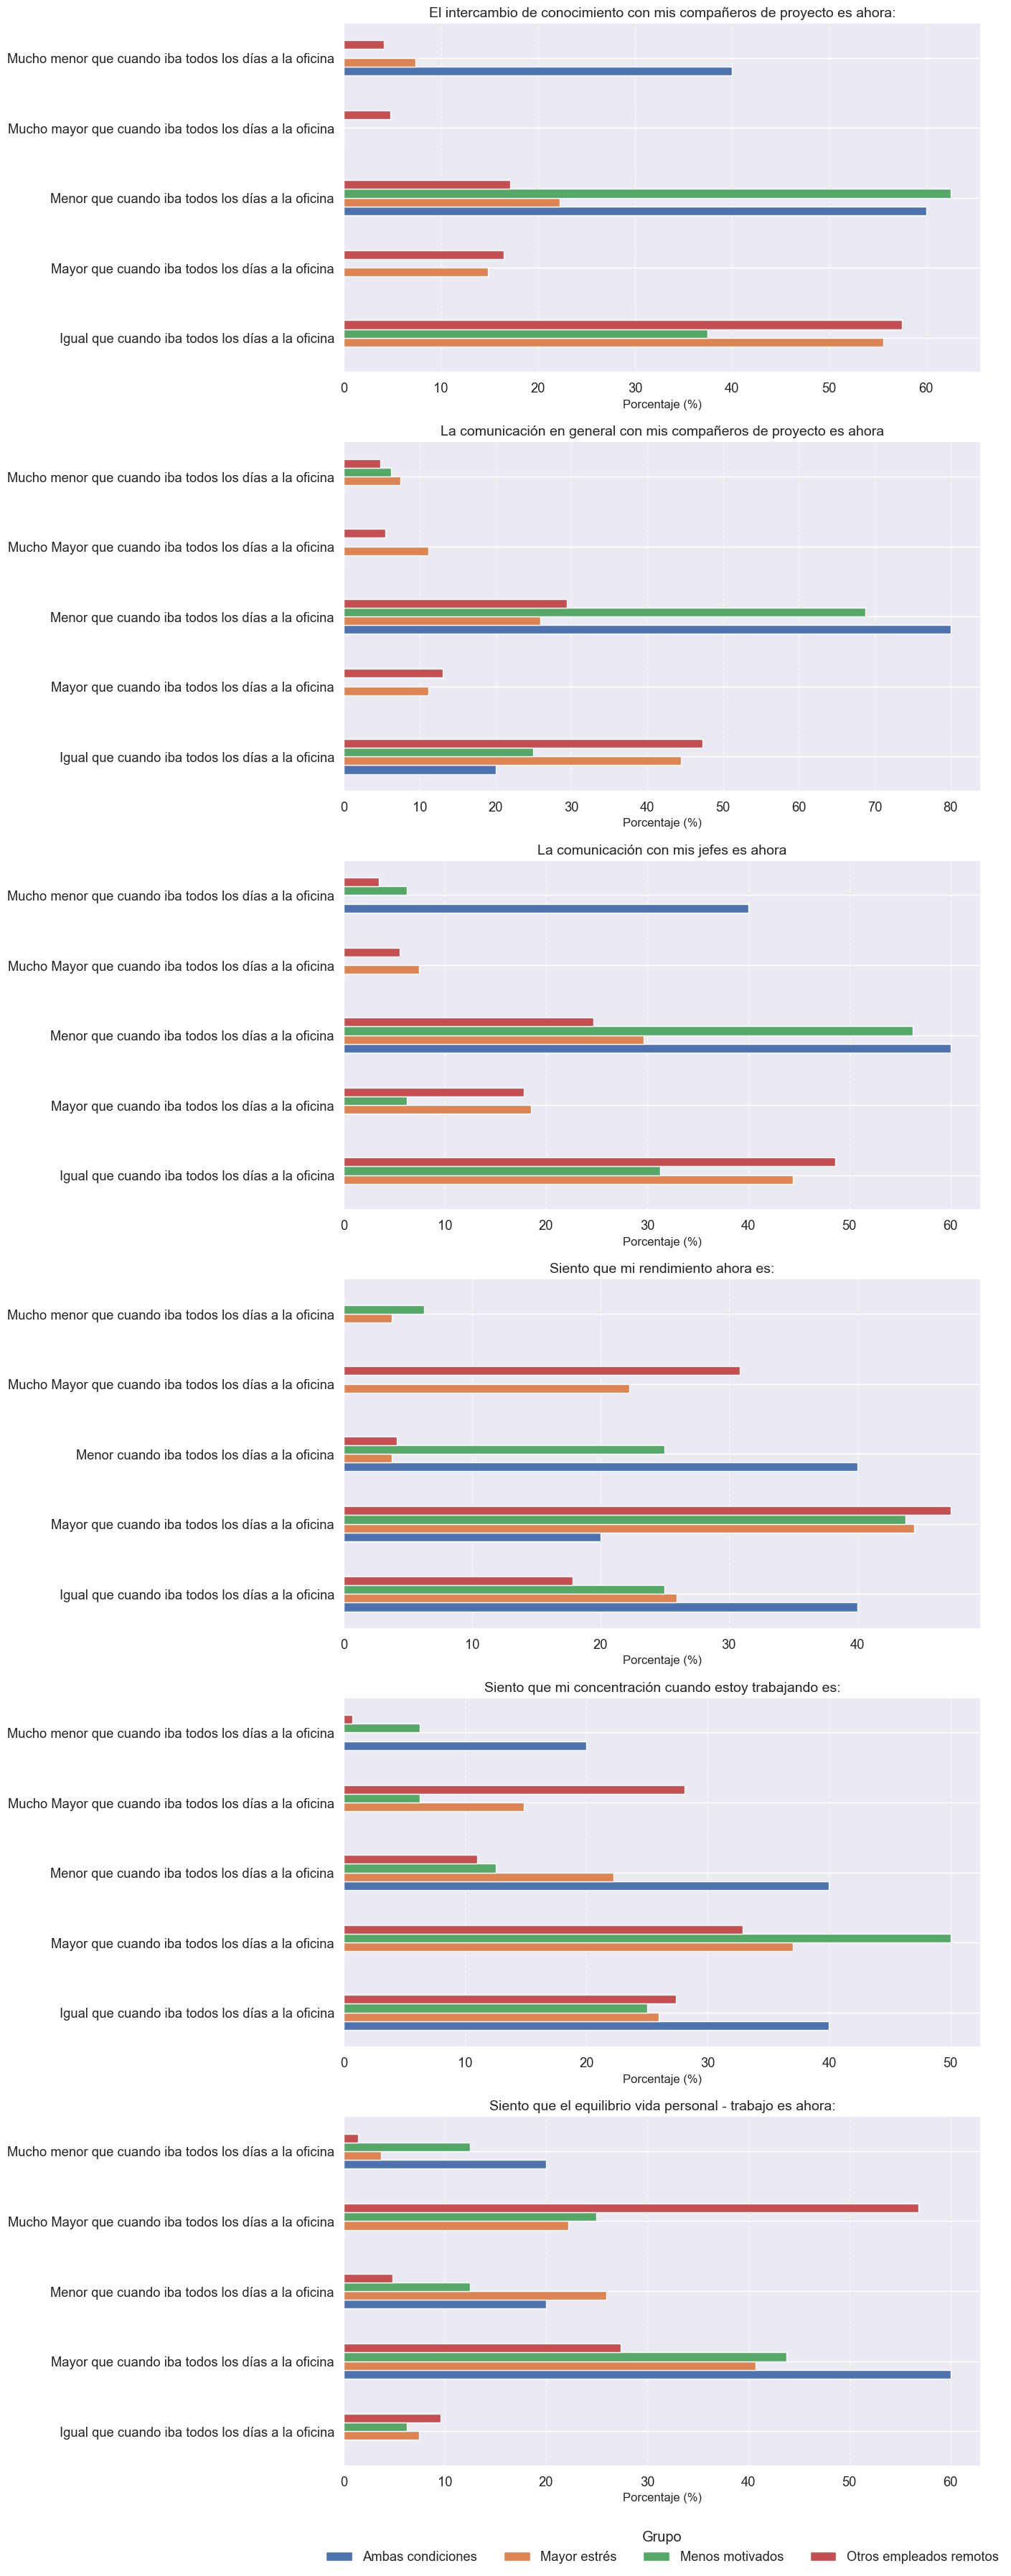

In [69]:
# Variables clave del trabajo remoto a analizar
remote_work_vars = [
    "El intercambio de conocimiento con mis compañeros de proyecto es ahora:",
    "La comunicación en general con mis compañeros de proyecto es ahora",
    "La comunicación con mis jefes es ahora",
    "Siento que mi rendimiento ahora es:",
    "Siento que mi concentración cuando estoy trabajando es:",
    "Siento que el equilibrio vida personal - trabajo es ahora:"
]

# Crear una figura con subplots
fig, axes = plt.subplots(len(remote_work_vars), 1, figsize=(14, 6*len(remote_work_vars)))

for i, var in enumerate(remote_work_vars):
    # Crear crosstab
    cross_tab = pd.crosstab(remote_employees[var], remote_employees['grupo'], normalize='columns') * 100
    
    # Visualizar
    cross_tab.plot(kind='barh', ax=axes[i])
    axes[i].set_title(f"{var}", fontsize=14)
    axes[i].set_xlabel("Porcentaje (%)", fontsize=12)
    axes[i].set_ylabel("", fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)
    
    # Solo mostrar leyenda en el último gráfico
    if i == len(remote_work_vars) - 1:
        axes[i].legend(title="Grupo", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

In [30]:
# Crear visualización interactiva para trabajo remoto con Plotly
# Seleccionamos algunas variables clave para no saturar el gráfico
key_remote_vars = [
    "El intercambio de conocimiento con mis compañeros de proyecto es ahora:",
    "Siento que mi rendimiento ahora es:",
    "Siento que el equilibrio vida personal - trabajo es ahora:"
]

# Preparar datos para visualización
plot_data = []

for var in key_remote_vars:
    # Calcular porcentajes por grupo
    cross_tab = pd.crosstab(remote_employees[var], remote_employees['grupo'], normalize='columns') * 100
    
    # Ordenar las respuestas de manera consistente
    order = [
        "Mucho menor que cuando iba todos los días a la oficina",
        "Menor que cuando iba todos los días a la oficina",
        "Igual que cuando iba todos los días a la oficina",
        "Mayor que cuando iba todos los días a la oficina",
        "Mucho Mayor que cuando iba todos los días a la oficina"
    ]
    ordered_idx = [idx for idx in order if idx in cross_tab.index]
    cross_tab = cross_tab.reindex(ordered_idx)
    
    # Añadir a los datos del gráfico
    for group in cross_tab.columns:
        for response in cross_tab.index:
            plot_data.append({
                'Variable': var,
                'Respuesta': response,
                'Grupo': group,
                'Porcentaje': cross_tab.loc[response, group]
            })

# Crear dataframe para plotly
plot_df = pd.DataFrame(plot_data)

# Crear visualización interactiva
fig = px.bar(
    plot_df,
    x="Porcentaje",
    y="Respuesta",
    color="Grupo",
    facet_col="Variable",
    facet_col_wrap=1,  # Una variable por fila
    height=300 * len(key_remote_vars),  # Ajustar altura según número de variables
    width=1000,
    title="Comparación de Aspectos Clave del Trabajo Remoto por Grupo",
    labels={"Porcentaje": "Porcentaje (%)", "Respuesta": "", "Variable": "Aspecto del Trabajo Remoto"}
)

fig.update_layout(
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5),
    legend_title="Grupo"
)

fig.show()

## 7. Análisis de Factores Relacionados con Motivación y Estrés

Identificamos y analizamos los factores clave que influyen en la motivación y el estrés en el entorno de trabajo remoto.

In [31]:
# Variables relacionadas con motivación
motivation_vars = [
    "Siento que mi nivel de motivación en el trabajo es:",
    "Siento que mi empresa me aprecia:",
    "Siento que las acciones de motivación de personal de mi empresa son:",
    "En términos de disfrute en el trabajo siento que ahora es:",
    "Siento que el nivel de interés hacia mi trabajo ahora es:",
    "El sentimiento de pertenencia a mi empresa es ahora",
    "Siento que mi nivel de influencia en mi equipo de trabajo es ahora:",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora",
    "Siento que mi creatividad es:"
]

# Variables relacionadas con estrés
stress_vars = [
    "Siento que mi nivel de estrés es:",
    "Siento que el nivel de presión por terminar las tareas ahora es:",
    "Siento que mis reacciones de enojo o molestia ahora son:",
    "Siento que mi nivel de frustración con relación al trabajo es:",
    "Siento que las interrupciones externas ahora son:",
    "Siento que los problemas de comunicación ahora son:",
    "Siento que los problemas de coordinación afectan a mi estrés:",
    "Siento que el hecho de trabajar con personas que tienen otros horarios afecta a mi estrés:",
    "Siento que mi miedo a perder el trabajo es ahora:"
]

In [38]:
# Función para visualizar y analizar factores de motivación o estrés por grupo
def analyze_factors(df, variables, title, focus_groups=None, figsize=(16, 12)):
    # Si se especifican grupos de enfoque, filtrar el DataFrame
    if focus_groups:
        df_filtered = df[df['grupo'].isin(focus_groups)]
    else:
        df_filtered = df
    
    # Crear figura con múltiples subplots
    valid_variables = [var for var in variables if var in df.columns]
    if not valid_variables:
        print("Ninguna de las variables proporcionadas existe en el DataFrame.")
        return {}
    
    fig, axes = plt.subplots(len(valid_variables), 1, figsize=figsize)
    
    # Ajustar para el caso de una sola variable
    if len(valid_variables) == 1:
        axes = [axes]
    
    results = {}
    
    for i, var in enumerate(valid_variables):
        # Verificar si la variable existe
        if var not in df_filtered.columns:
            continue
            
        # Crear crosstab
        cross_tab = pd.crosstab(df_filtered[var], df_filtered['grupo'], normalize='columns') * 100
        results[var] = cross_tab
        
        # Resto del código como antes...
        
        # Determinar orden de las respuestas (de negativo a positivo)
        order = [
            "Mucho menor que cuando iba todos los días a la oficina",
            "Menor que cuando iba todos los días a la oficina",
            "Igual que cuando iba todos los días a la oficina",
            "Mayor que cuando iba todos los días a la oficina",
            "Mucho Mayor que cuando iba todos los días a la oficina",
            "Mucho menores que cuando iba todos los días a la oficina",
            "Menores que cuando iba todos los días a la oficina",
            "Iguales que cuando iba todos los días a la oficina",
            "Mayores que cuando iba todos los días a la oficina",
            "Mucho mayores que cuando iba todos los días a la oficina",
            "Totalmente en desacuerdo",
            "En desacuerdo",
            "Neutral",
            "De acuerdo",
            "Totalmente de acuerdo"
        ]
        
        # Ordenar las respuestas si están en el orden predefinido
        ordered_idx = [idx for idx in order if idx in cross_tab.index]
        if ordered_idx:
            cross_tab = cross_tab.reindex(ordered_idx)
        
        # Visualizar
        cross_tab.plot(kind='barh', ax=axes[i])
        var_shortened = var[:50] + '...' if len(var) > 50 else var  # Acortar nombres muy largos
        axes[i].set_title(var_shortened, fontsize=12)
        axes[i].set_xlabel("Porcentaje (%)", fontsize=10)
        axes[i].set_ylabel("", fontsize=10)
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)
        
        # Solo mostrar leyenda en el último gráfico
        if i == len(variables) - 1:
            axes[i].legend(title="Grupo", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
        else:
            axes[i].get_legend().remove()
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return results

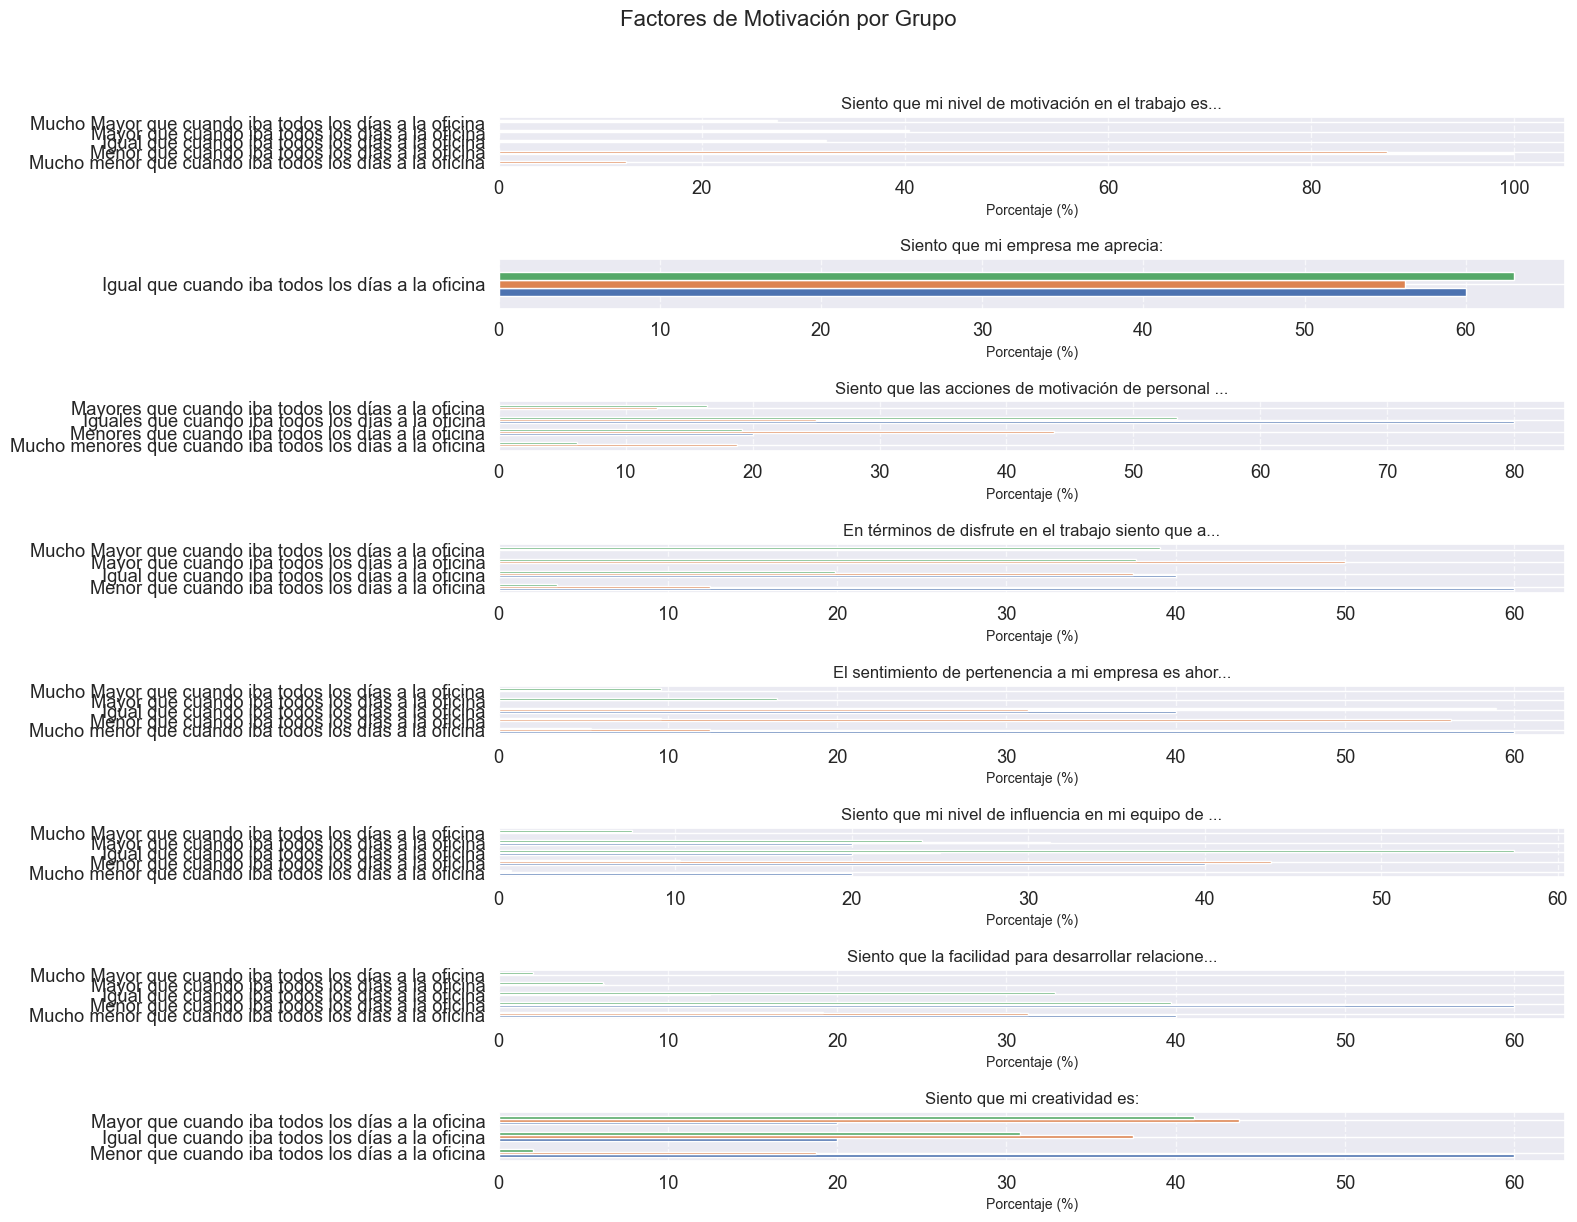

In [39]:
# Analizar factores de motivación para el grupo menos motivado y el grupo con ambas condiciones
motivation_results = analyze_factors(
    remote_employees, 
    motivation_vars, 
    "Factores de Motivación por Grupo",
    focus_groups=['Menos motivados', 'Ambas condiciones', 'Otros empleados remotos']
)

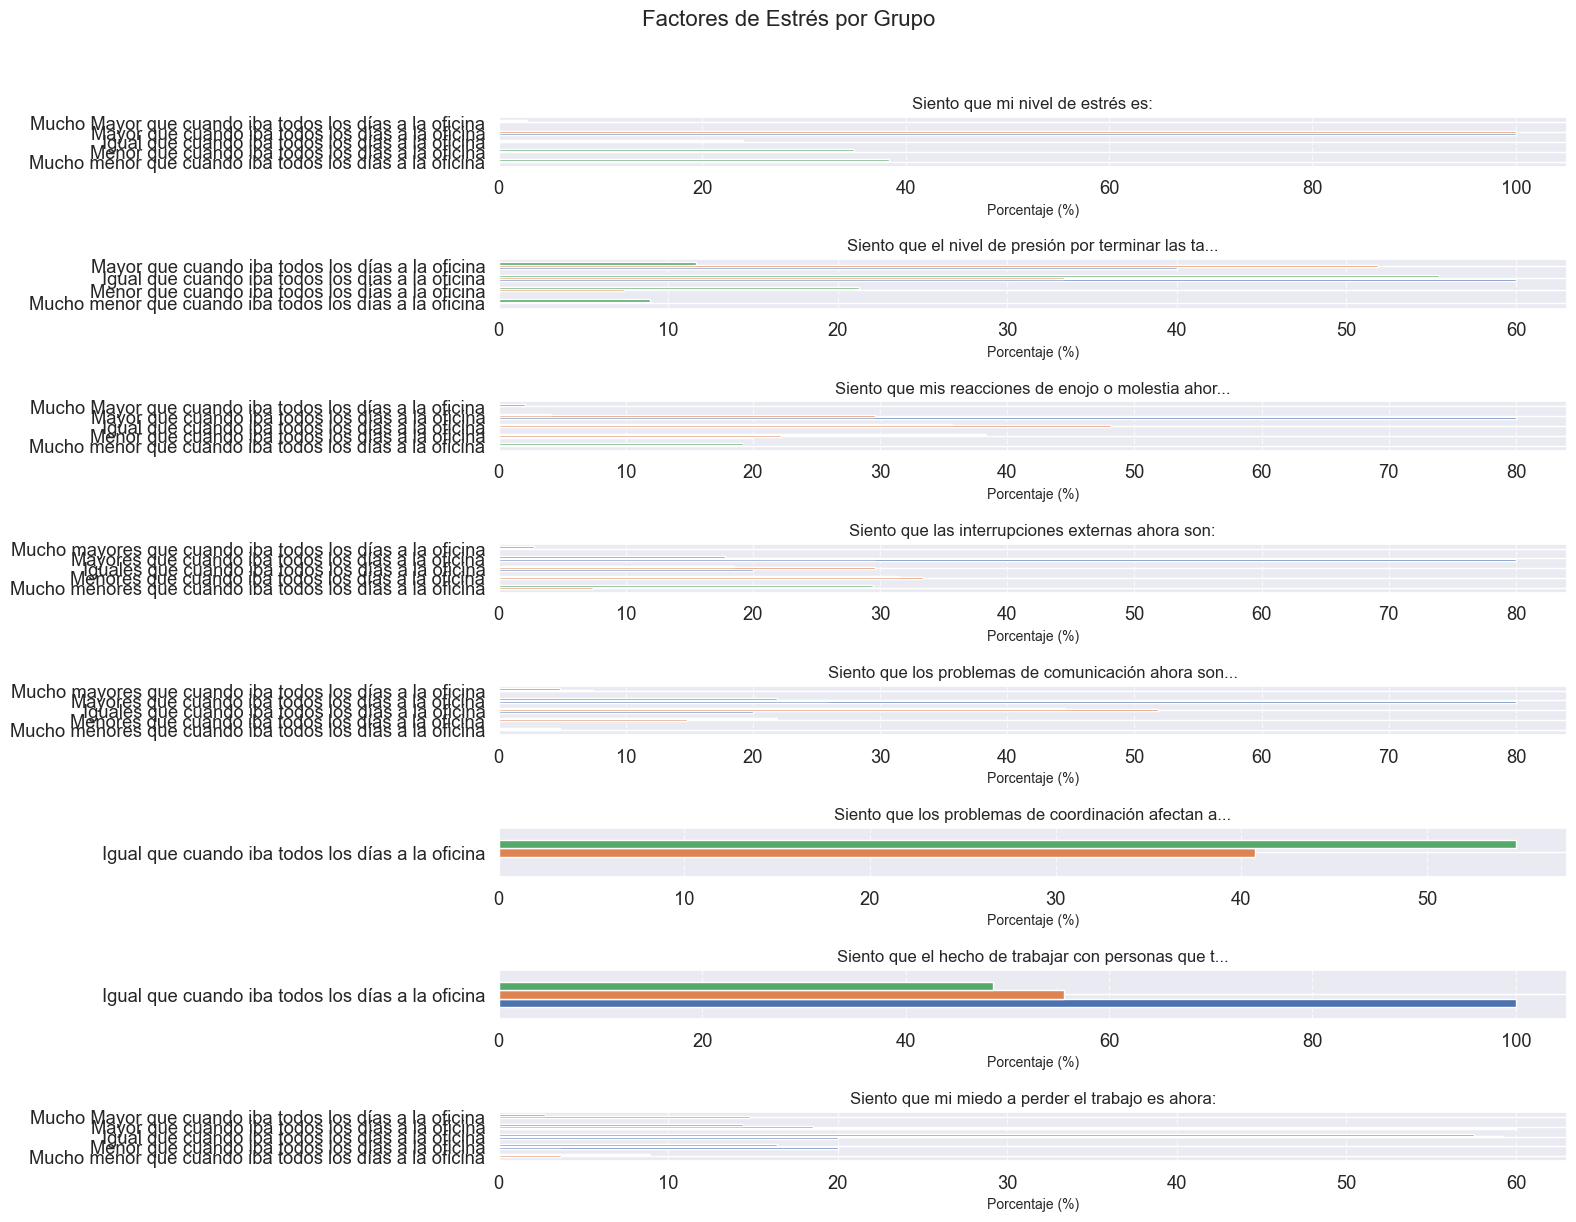

In [40]:
# Analizar factores de estrés para el grupo con mayor estrés y el grupo con ambas condiciones
stress_results = analyze_factors(
    remote_employees, 
    stress_vars, 
    "Factores de Estrés por Grupo",
    focus_groups=['Mayor estrés', 'Ambas condiciones', 'Otros empleados remotos']
)

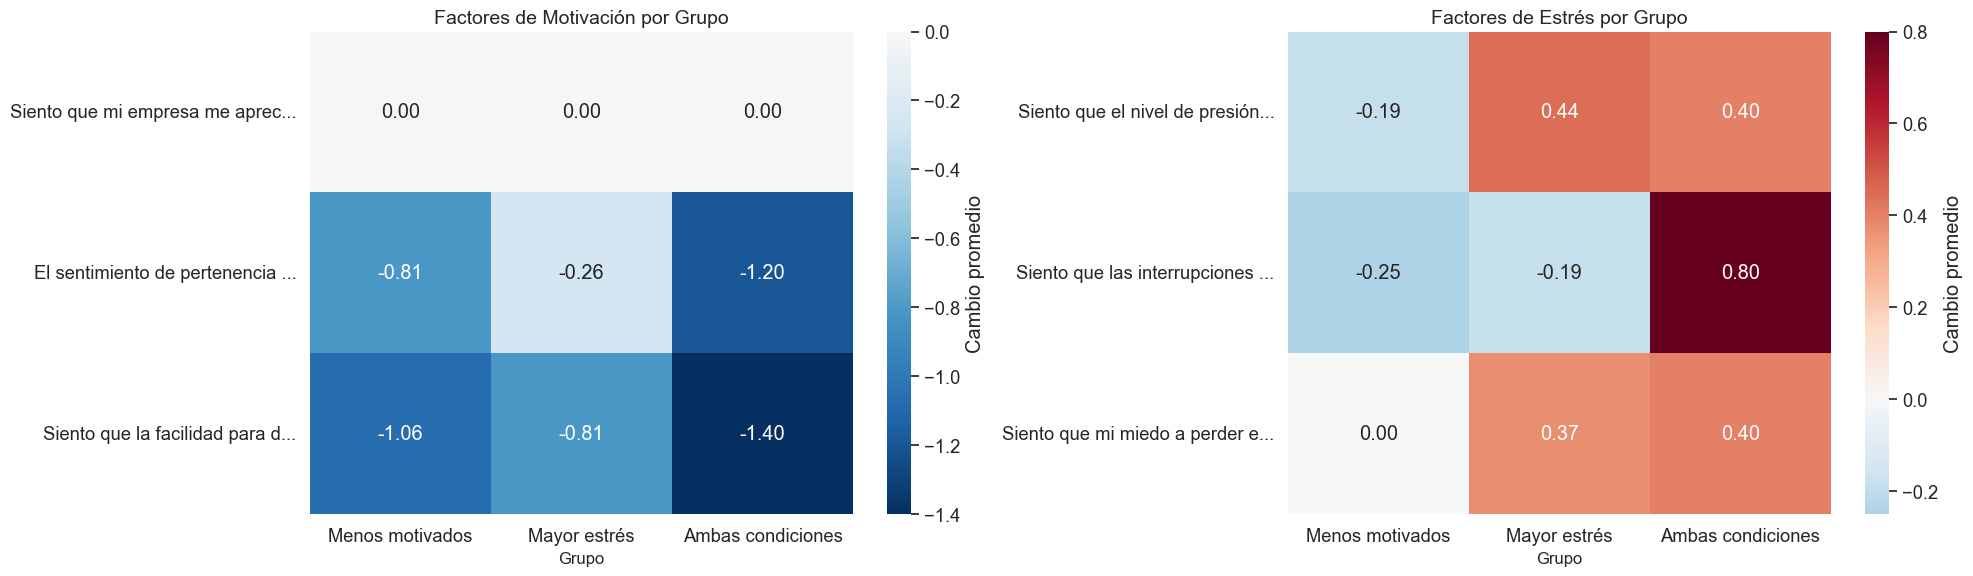

In [41]:
# Visualización interactiva: Heatmap de los factores de motivación y estrés
# Seleccionamos algunos factores clave para cada aspecto

key_motivation_vars = [
    "Siento que mi empresa me aprecia:",
    "El sentimiento de pertenencia a mi empresa es ahora",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora"
]

key_stress_vars = [
    "Siento que el nivel de presión por terminar las tareas ahora es:",
    "Siento que las interrupciones externas ahora son:",
    "Siento que mi miedo a perder el trabajo es ahora:"
]

# Crear una matriz para el heatmap
# Para simplificar, convertiremos las respuestas a valores numéricos
def response_to_score(response):
    mapping = {
        'Mucho menor que cuando iba todos los días a la oficina': -2,
        'Menor que cuando iba todos los días a la oficina': -1,
        'Igual que cuando iba todos los días a la oficina': 0,
        'Mayor que cuando iba todos los días a la oficina': 1,
        'Mucho Mayor que cuando iba todos los días a la oficina': 2,
        'Mucho menores que cuando iba todos los días a la oficina': -2,
        'Menores que cuando iba todos los días a la oficina': -1,
        'Iguales que cuando iba todos los días a la oficina': 0,
        'Mayores que cuando iba todos los días a la oficina': 1,
        'Mucho mayores que cuando iba todos los días a la oficina': 2,
        'Totalmente en desacuerdo': -2,
        'En desacuerdo': -1,
        'Neutral': 0,
        'De acuerdo': 1,
        'Totalmente de acuerdo': 2
    }
    return mapping.get(response, 0)  # Valor predeterminado 0 si no se encuentra

# Crear matrices para heatmap
motivation_matrix = {}
stress_matrix = {}

for group in ['Menos motivados', 'Mayor estrés', 'Ambas condiciones']:
    group_data = remote_employees[remote_employees['grupo'] == group]
    
    # Calcular valores promedio para factores de motivación
    motivation_scores = []
    for var in key_motivation_vars:
        scores = group_data[var].apply(response_to_score)
        avg_score = scores.mean()
        motivation_scores.append(avg_score)
    motivation_matrix[group] = motivation_scores
    
    # Calcular valores promedio para factores de estrés
    stress_scores = []
    for var in key_stress_vars:
        scores = group_data[var].apply(response_to_score)
        avg_score = scores.mean()
        stress_scores.append(avg_score)
    stress_matrix[group] = stress_scores

# Convertir a DataFrames
motivation_df = pd.DataFrame(motivation_matrix, index=[var[:30] + '...' for var in key_motivation_vars])
stress_df = pd.DataFrame(stress_matrix, index=[var[:30] + '...' for var in key_stress_vars])

# Visualizar heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap de factores de motivación
sns.heatmap(motivation_df, annot=True, cmap='RdBu_r', center=0, ax=ax1, fmt='.2f', cbar_kws={'label': 'Cambio promedio'})
ax1.set_title('Factores de Motivación por Grupo', fontsize=14)
ax1.set_ylabel('')
ax1.set_xlabel('Grupo', fontsize=12)

# Heatmap de factores de estrés
sns.heatmap(stress_df, annot=True, cmap='RdBu_r', center=0, ax=ax2, fmt='.2f', cbar_kws={'label': 'Cambio promedio'})
ax2.set_title('Factores de Estrés por Grupo', fontsize=14)
ax2.set_ylabel('')
ax2.set_xlabel('Grupo', fontsize=12)

plt.tight_layout()
plt.show()

In [42]:
# Gráfico de radar para comparar perfiles multidimensionales

# Seleccionamos variables clave tanto de motivación como de estrés
radar_vars = [
    "Siento que mi empresa me aprecia:",
    "El sentimiento de pertenencia a mi empresa es ahora",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora",
    "Siento que el nivel de presión por terminar las tareas ahora es:",
    "Siento que las interrupciones externas ahora son:",
    "Siento que mi miedo a perder el trabajo es ahora:",
    "Siento que el equilibrio vida personal - trabajo es ahora:",
    "Siento que mi rendimiento ahora es:"
]

# Acortar nombres para el gráfico
radar_labels = [
    "Aprecio de empresa",
    "Pertenencia",
    "Relaciones personales",
    "Presión por tareas",
    "Interrupciones",
    "Miedo a perder trabajo",
    "Equilibrio vida-trabajo",
    "Rendimiento"
]

# Crear matrices para gráfico de radar
radar_matrix = {}

for group in ['Menos motivados', 'Mayor estrés', 'Ambas condiciones']:
    group_data = remote_employees[remote_employees['grupo'] == group]
    
    # Calcular valores promedio
    scores = []
    for var in radar_vars:
        var_scores = group_data[var].apply(response_to_score)
        avg_score = var_scores.mean()
        # Normalizar a escala 0-1 (de -2 a 2 -> 0 a 1)
        normalized_score = (avg_score + 2) / 4
        scores.append(normalized_score)
    radar_matrix[group] = scores

# Crear gráfico de radar con Plotly
fig = go.Figure()

# Colores para cada grupo
colors = {
    'Menos motivados': 'rgba(31, 119, 180, 0.8)',
    'Mayor estrés': 'rgba(255, 127, 14, 0.8)',
    'Ambas condiciones': 'rgba(214, 39, 40, 0.8)'
}

for group in radar_matrix:
    fig.add_trace(go.Scatterpolar(
        r=radar_matrix[group],
        theta=radar_labels,
        fill='toself',
        name=group,
        line_color=colors[group],
        opacity=0.8
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    title="Perfil Multidimensional por Grupo",
    showlegend=True,
    height=600,
    width=800
)

fig.show()

## 8. Análisis Estadísticos

Realizamos pruebas estadísticas para identificar diferencias significativas entre grupos y analizamos correlaciones entre variables clave.

In [43]:
# Función para convertir variables categóricas a numéricas para análisis estadístico
def prepare_numeric_data(df, variables):
    df_numeric = df.copy()
    
    for var in variables:
        if var in df.columns:
            df_numeric[f"{var}_numeric"] = df[var].apply(response_to_score)
    
    return df_numeric

In [44]:
# Preparar datos numéricos para análisis estadístico
all_vars = motivation_vars + stress_vars + remote_work_vars
remote_employees_numeric = prepare_numeric_data(remote_employees, all_vars)

# Verificar las primeras filas de los datos numéricos
numeric_cols = [col for col in remote_employees_numeric.columns if col.endswith('_numeric')]
remote_employees_numeric[['grupo'] + numeric_cols].head()

,grupo,Siento que mi nivel de motivación en el trabajo es:_numeric,Siento que mi empresa me aprecia:_numeric,Siento que las acciones de motivación de personal de mi empresa son:_numeric,En términos de disfrute en el trabajo siento que ahora es:_numeric,El sentimiento de pertenencia a mi empresa es ahora_numeric,Siento que mi nivel de influencia en mi equipo de trabajo es ahora:_numeric,Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora_numeric,Siento que mi creatividad es:_numeric,Siento que mi nivel de estrés es:_numeric,Siento que el nivel de presión por terminar las tareas ahora es:_numeric,Siento que mis reacciones de enojo o molestia ahora son:_numeric,Siento que las interrupciones externas ahora son:_numeric,Siento que los problemas de comunicación ahora son:_numeric,Siento que los problemas de coordinación afectan a mi estrés:_numeric,Siento que el hecho de trabajar con personas que tienen otros horarios afecta a mi estrés:_numeric,Siento que mi miedo a perder el trabajo es ahora:_numeric,El intercambio de conocimiento con mis compañeros de proyecto es ahora:_numeric,La comunicación en general con mis compañeros de proyecto es ahora_numeric,La comunicación con mis jefes es ahora_numeric,Siento que mi rendimiento ahora es:_numeric,Siento que mi concentración cuando estoy trabajando es:_numeric,Siento que el equilibrio vida personal - trabajo es ahora:_numeric
0,Otros empleados remotos,2,0,0,2,0,-1,-1,0,0,1,-1,1,-1,0,0,1,0,0,1,1,2,2
1,Otros empleados remotos,1,0,0,1,0,0,0,0,-1,0,0,-2,0,0,0,0,0,0,0,1,2,2
2,Otros empleados remotos,1,0,0,1,-1,1,0,1,-2,0,0,-2,0,0,0,-1,1,1,1,1,1,2
3,Otros empleados remotos,2,0,0,2,0,-1,-2,0,-2,0,-2,-2,0,0,0,1,0,-1,0,2,2,2
4,Otros empleados remotos,0,0,0,2,0,0,0,1,0,0,0,0,1,0,0,0,-1,0,0,0,0,2


In [45]:
# Realizar pruebas estadísticas para identificar diferencias significativas entre grupos
statistical_results = []

for var in numeric_cols:
    # Preparar grupos para comparación
    less_motivated_data = remote_employees_numeric[remote_employees_numeric['grupo'] == 'Menos motivados'][var].dropna()
    more_stressed_data = remote_employees_numeric[remote_employees_numeric['grupo'] == 'Mayor estrés'][var].dropna()
    both_conditions_data = remote_employees_numeric[remote_employees_numeric['grupo'] == 'Ambas condiciones'][var].dropna()
    other_remote_data = remote_employees_numeric[remote_employees_numeric['grupo'] == 'Otros empleados remotos'][var].dropna()
    
    # Realizar pruebas estadísticas solo si hay suficientes datos en cada grupo
    # Comparación 1: Menos motivados vs Otros empleados remotos
    if len(less_motivated_data) >= 5 and len(other_remote_data) >= 5:
        try:
            t_stat, p_value = stats.ttest_ind(less_motivated_data, other_remote_data, equal_var=False)
            statistical_results.append({
                'Variable': var.replace('_numeric', ''),
                'Comparación': 'Menos motivados vs Otros',
                'Estadístico t': t_stat,
                'Valor p': p_value,
                'Significativo': p_value < 0.05
            })
        except Exception as e:
            print(f"Error en prueba para {var}, Menos motivados vs Otros: {e}")
    
    # Comparación 2: Mayor estrés vs Otros empleados remotos
    if len(more_stressed_data) >= 5 and len(other_remote_data) >= 5:
        try:
            t_stat, p_value = stats.ttest_ind(more_stressed_data, other_remote_data, equal_var=False)
            statistical_results.append({
                'Variable': var.replace('_numeric', ''),
                'Comparación': 'Mayor estrés vs Otros',
                'Estadístico t': t_stat,
                'Valor p': p_value,
                'Significativo': p_value < 0.05
            })
        except Exception as e:
            print(f"Error en prueba para {var}, Mayor estrés vs Otros: {e}")
    
    # Comparación 3: Ambas condiciones vs Otros empleados remotos
    if len(both_conditions_data) >= 5 and len(other_remote_data) >= 5:
        try:
            t_stat, p_value = stats.ttest_ind(both_conditions_data, other_remote_data, equal_var=False)
            statistical_results.append({
                'Variable': var.replace('_numeric', ''),
                'Comparación': 'Ambas condiciones vs Otros',
                'Estadístico t': t_stat,
                'Valor p': p_value,
                'Significativo': p_value < 0.05
            })
        except Exception as e:
            print(f"Error en prueba para {var}, Ambas condiciones vs Otros: {e}")
            
# Convertir resultados a DataFrame y filtrar solo diferencias significativas
stats_df = pd.DataFrame(statistical_results)
significant_results = stats_df[stats_df['Significativo'] == True].sort_values('Valor p')

# Mostrar resultados significativos
print(f"Se encontraron {len(significant_results)} diferencias estadísticamente significativas (p < 0.05):\n")
significant_results[['Variable', 'Comparación', 'Estadístico t', 'Valor p']].head(20)

Se encontraron 29 diferencias estadísticamente significativas (p < 0.05):



,Variable,Comparación,Estadístico t,Valor p
2,Siento que mi nivel de motivación en el trabaj...,Ambas condiciones vs Otros,-30.509290,5.618716e-65
25,Siento que mi nivel de estrés es:,Mayor estrés vs Otros,26.676134,8.557669e-58
26,Siento que mi nivel de estrés es:,Ambas condiciones vs Otros,26.676134,8.557669e-58
0,Siento que mi nivel de motivación en el trabaj...,Menos motivados vs Otros,-19.465868,1.689453e-20
28,Siento que el nivel de presión por terminar la...,Mayor estrés vs Otros,5.157843,6.435413e-06
31,Siento que mis reacciones de enojo o molestia ...,Mayor estrés vs Otros,4.773468,2.204945e-05
12,El sentimiento de pertenencia a mi empresa es ...,Menos motivados vs Otros,-5.333104,2.335152e-05
51,La comunicación en general con mis compañeros ...,Menos motivados vs Otros,-4.263492,2.470983e-04
35,Siento que las interrupciones externas ahora son:,Ambas condiciones vs Otros,6.634565,5.516161e-04
48,El intercambio de conocimiento con mis compañe...,Menos motivados vs Otros,-3.886353,7.893477e-04


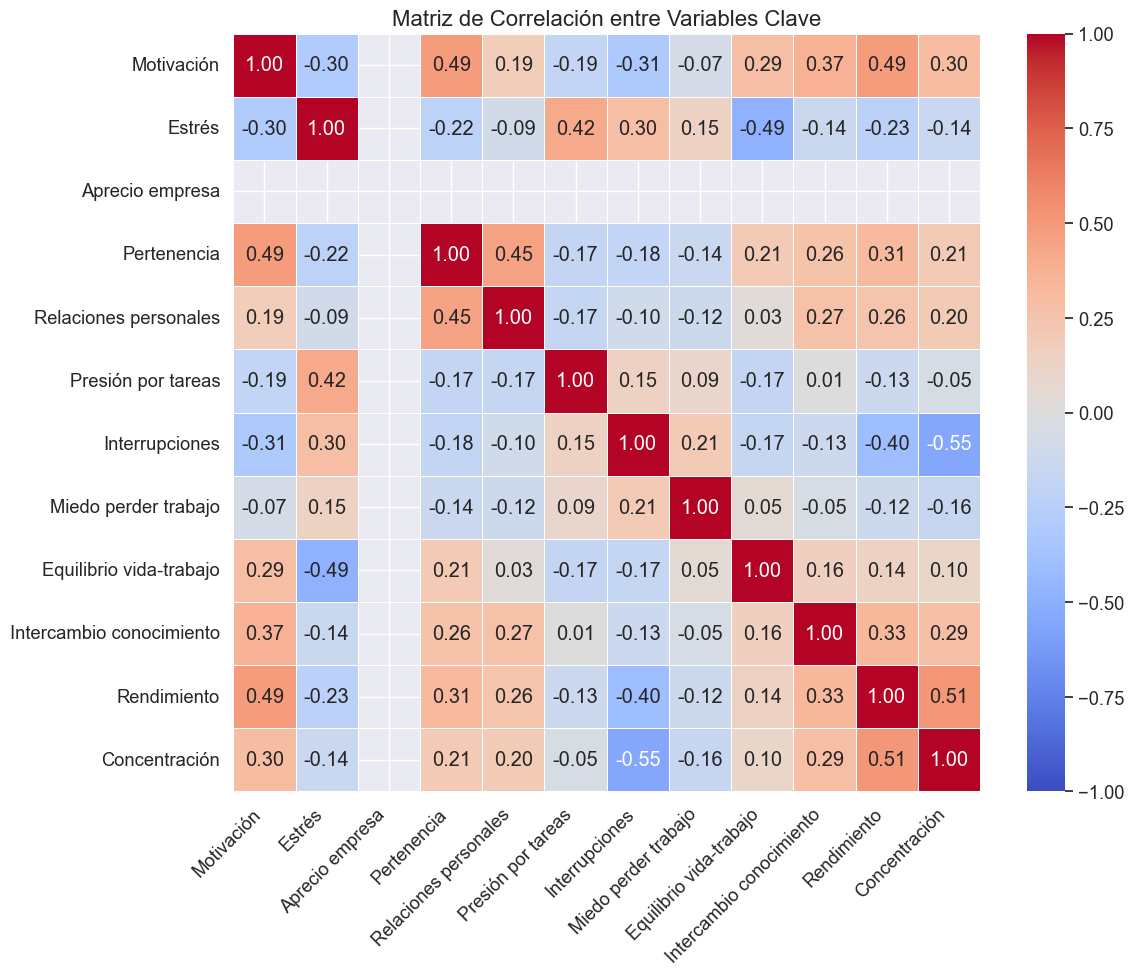

In [46]:
# Análisis de correlación entre variables clave
# Seleccionamos un subconjunto de variables para una matriz de correlación más clara
key_vars_numeric = [
    "Siento que mi nivel de motivación en el trabajo es:_numeric",
    "Siento que mi nivel de estrés es:_numeric",
    "Siento que mi empresa me aprecia:_numeric",
    "El sentimiento de pertenencia a mi empresa es ahora_numeric",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora_numeric",
    "Siento que el nivel de presión por terminar las tareas ahora es:_numeric",
    "Siento que las interrupciones externas ahora son:_numeric",
    "Siento que mi miedo a perder el trabajo es ahora:_numeric",
    "Siento que el equilibrio vida personal - trabajo es ahora:_numeric",
    "El intercambio de conocimiento con mis compañeros de proyecto es ahora:_numeric",
    "Siento que mi rendimiento ahora es:_numeric",
    "Siento que mi concentración cuando estoy trabajando es:_numeric"
]

# Crear matriz de correlación
correlation_matrix = remote_employees_numeric[key_vars_numeric].corr()

# Crear labels más cortos para visualización
short_labels = {
    "Siento que mi nivel de motivación en el trabajo es:_numeric": "Motivación",
    "Siento que mi nivel de estrés es:_numeric": "Estrés",
    "Siento que mi empresa me aprecia:_numeric": "Aprecio empresa",
    "El sentimiento de pertenencia a mi empresa es ahora_numeric": "Pertenencia",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora_numeric": "Relaciones personales",
    "Siento que el nivel de presión por terminar las tareas ahora es:_numeric": "Presión por tareas",
    "Siento que las interrupciones externas ahora son:_numeric": "Interrupciones",
    "Siento que mi miedo a perder el trabajo es ahora:_numeric": "Miedo perder trabajo",
    "Siento que el equilibrio vida personal - trabajo es ahora:_numeric": "Equilibrio vida-trabajo",
    "El intercambio de conocimiento con mis compañeros de proyecto es ahora:_numeric": "Intercambio conocimiento",
    "Siento que mi rendimiento ahora es:_numeric": "Rendimiento",
    "Siento que mi concentración cuando estoy trabajando es:_numeric": "Concentración"
}

correlation_matrix = correlation_matrix.rename(index=short_labels, columns=short_labels)

# Visualizar matriz de correlación con seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables Clave', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
# Visualización interactiva de correlaciones
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Matriz de Correlación Interactiva',
    height=800,
    width=900,
    zmin=-1,
    zmax=1
)

fig.update_layout(
    xaxis_title='',
    yaxis_title='',
)

fig.show()

## 9. Modelos Predictivos Simples

Desarrollamos modelos predictivos simples para identificar qué factores son más importantes para predecir la disminución de motivación y el aumento de estrés en el trabajo remoto.

In [48]:
# Preparar datos para los modelos predictivos
# Primero creamos variables binarias (target) para cada condición

# Target para motivación: 1 si tiene menor motivación, 0 en caso contrario
remote_employees_numeric['target_motivacion'] = remote_employees.apply(
    lambda row: 1 if row['grupo'] in ['Menos motivados', 'Ambas condiciones'] else 0, 
    axis=1
)

# Target para estrés: 1 si tiene mayor estrés, 0 en caso contrario
remote_employees_numeric['target_estres'] = remote_employees.apply(
    lambda row: 1 if row['grupo'] in ['Mayor estrés', 'Ambas condiciones'] else 0, 
    axis=1
)

# Mostrar la distribución de las variables target
print("Distribución de empleados por nivel de motivación:")
print(remote_employees_numeric['target_motivacion'].value_counts())
print("\nDistribución de empleados por nivel de estrés:")
print(remote_employees_numeric['target_estres'].value_counts())

Distribución de empleados por nivel de motivación:
target_motivacion
0    173
1     21
Name: count, dtype: int64

Distribución de empleados por nivel de estrés:
target_estres
0    162
1     32
Name: count, dtype: int64


In [49]:
# Seleccionar variables predictoras para el modelo de motivación
# No incluimos la variable target directamente
predictors_motivation = [
    col for col in numeric_cols 
    if not col.startswith("Siento que mi nivel de motivación en el trabajo es:") and
       not col.startswith("Siento que mi nivel de estrés es:")
]

# Seleccionar variables predictoras para el modelo de estrés
predictors_stress = [
    col for col in numeric_cols 
    if not col.startswith("Siento que mi nivel de motivación en el trabajo es:") and
       not col.startswith("Siento que mi nivel de estrés es:")
]

# Verificar que tenemos suficientes datos completos
X_motivation = remote_employees_numeric[predictors_motivation].dropna()
y_motivation = remote_employees_numeric.loc[X_motivation.index, 'target_motivacion']

X_stress = remote_employees_numeric[predictors_stress].dropna()
y_stress = remote_employees_numeric.loc[X_stress.index, 'target_estres']

print(f"Datos disponibles para modelo de motivación: {len(X_motivation)}")
print(f"Datos disponibles para modelo de estrés: {len(X_stress)}")

Datos disponibles para modelo de motivación: 194
Datos disponibles para modelo de estrés: 194


Precisión del modelo para predecir menor motivación: 0.9153

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        53
           1       1.00      0.17      0.29         6

    accuracy                           0.92        59
   macro avg       0.96      0.58      0.62        59
weighted avg       0.92      0.92      0.89        59



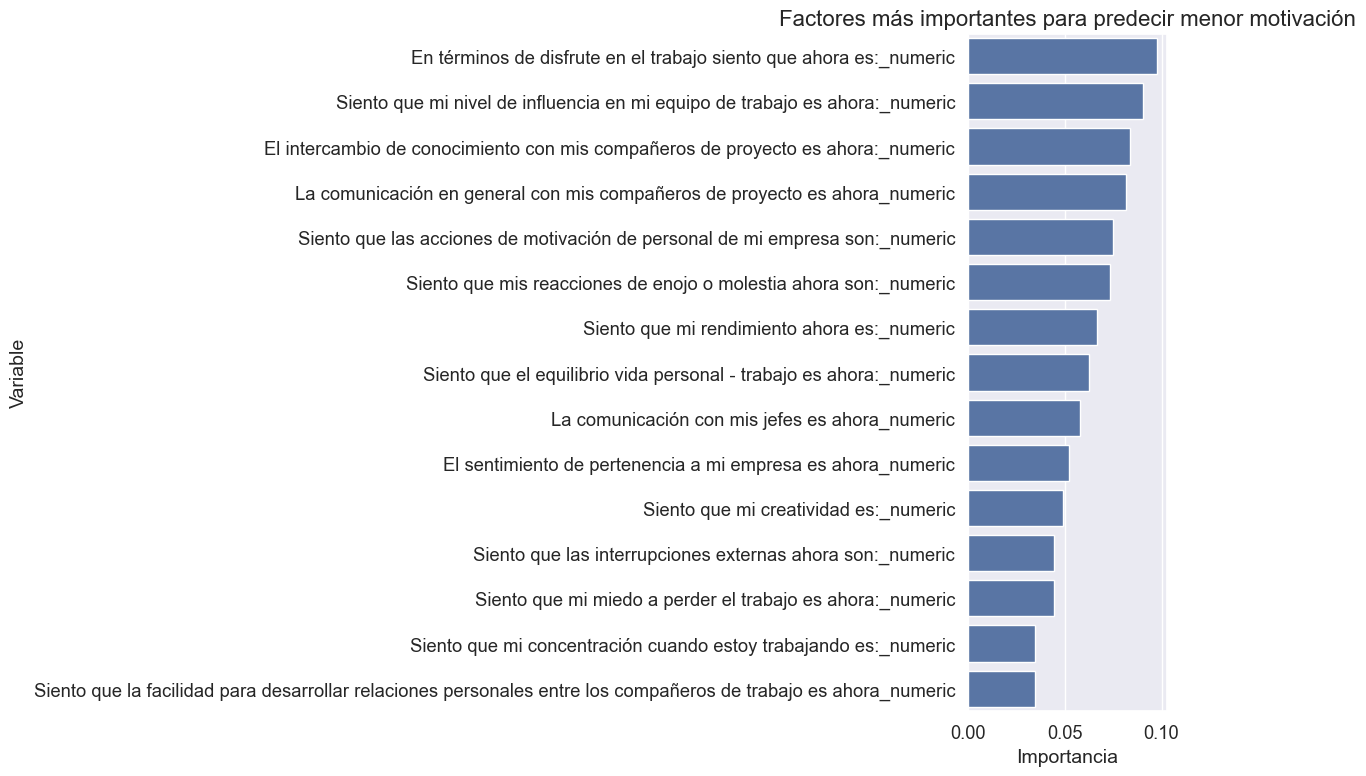

In [50]:
# Crear y entrenar modelo de Random Forest para predecir menor motivación
# Dividir los datos en entrenamiento y prueba
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_motivation, y_motivation, test_size=0.3, random_state=42, stratify=y_motivation
)

# Crear y entrenar el modelo
rf_model_motivation = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_motivation.fit(X_train_m, y_train_m)

# Evaluar el modelo
y_pred_m = rf_model_motivation.predict(X_test_m)
accuracy_m = accuracy_score(y_test_m, y_pred_m)
print(f"Precisión del modelo para predecir menor motivación: {accuracy_m:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_m, y_pred_m))

# Calcular importancia de características
feature_importances_m = pd.DataFrame({
    'Feature': predictors_motivation,
    'Importance': rf_model_motivation.feature_importances_
})
feature_importances_m = feature_importances_m.sort_values('Importance', ascending=False)

# Visualizar importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_m.head(15))
plt.title('Factores más importantes para predecir menor motivación', fontsize=16)
plt.xlabel('Importancia', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
# Visualización interactiva de importancia de características
# Crear versiones cortas de los nombres de las características
feature_importances_m['Feature_Short'] = feature_importances_m['Feature'].apply(
    lambda x: short_labels.get(x, x.replace('_numeric', '')[:30] + '...')
)

feature_importances_s['Feature_Short'] = feature_importances_s['Feature'].apply(
    lambda x: short_labels.get(x, x.replace('_numeric', '')[:30] + '...')
)

# Gráfico para modelo de motivación
fig1 = px.bar(
    feature_importances_m.head(10), 
    x='Importance', 
    y='Feature_Short',
    orientation='h',
    title='Top 10 Factores Predictivos de Menor Motivación',
    height=600,
    width=900
)

fig1.update_layout(
    xaxis_title='Importancia Relativa',
    yaxis_title='Factor',
    yaxis={'categoryorder':'total ascending'}
)

fig1.show()

# Gráfico para modelo de estrés
fig2 = px.bar(
    feature_importances_s.head(10), 
    x='Importance', 
    y='Feature_Short',
    orientation='h',
    title='Top 10 Factores Predictivos de Mayor Estrés',
    height=600,
    width=900
)

fig2.update_layout(
    xaxis_title='Importancia Relativa',
    yaxis_title='Factor',
    yaxis={'categoryorder':'total ascending'}
)

fig2.show()

In [ ]:
import nbconvert
import os

# Use your actual notebook path
notebook_path = "Analysis_Profiling.ipynb"
output_path = os.path.splitext(notebook_path)[0] + ".pdf"

# Convert to PDF
os.system(f"jupyter nbconvert --to pdf {notebook_path}")

-1